# **Machine Learning Analysis of Atmospheric CH₄ Time Series**

Following the previous analysis of atmospheric CO₂ using statistical time series models, this analysis applies a **machine learning approach** to atmospheric methane (CH₄) concentrations. The dataset contains **514 monthly observations from July 1983 to April 2026**, providing a long-term record of changes in atmospheric methane levels.

The analysis will investigate how different **machine learning methods** can be used to model and forecast the CH₄ time series. The focus will be on understanding the structure of the data, developing suitable predictive features, training and tuning models, and evaluating their forecasting performance.

The analysis uses a **univariate time-series framework**, where the primary source of predictive information is the historical CH₄ concentration itself. The specific feature engineering, modelling approaches, and evaluation procedures will be introduced and discussed in the sections that follow.


## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/ch4_mm_gl.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS")

print(df.head())

            year  month   decimal  average  average_unc    trend  trend_unc
date                                                                       
1983-07-01  1983      7  1983.542  1626.05         2.39  1635.18       1.46
1983-08-01  1983      8  1983.625  1628.02         2.93  1635.67       1.39
1983-09-01  1983      9  1983.708  1638.42         2.20  1636.23       1.31
1983-10-01  1983     10  1983.792  1644.81         1.47  1636.85       1.23
1983-11-01  1983     11  1983.875  1642.60         0.82  1637.55       1.15


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1983-07-01 00:00:00 to 2024-04-01 00:00:00
Number of observations: 490

Holdout data:
2024-05-01 00:00:00 to 2026-04-01 00:00:00
Number of observations: 24


## **2. Data analysis**
We begin with an exploratory analysis of the data to develop an understanding of the underlying characteristics of the time series. This initial analysis provides insights into key patterns and properties of the series, which will subsequently guide the feature-engineering process.

### **2.1 Raw Series Inspection**

The raw monthly CH₄ series is first visualized using the `average` variable concentration. This allows us to identify its main time-series characteristics, including overall trends, seasonal patterns, fluctuations, and any potential anomalies.

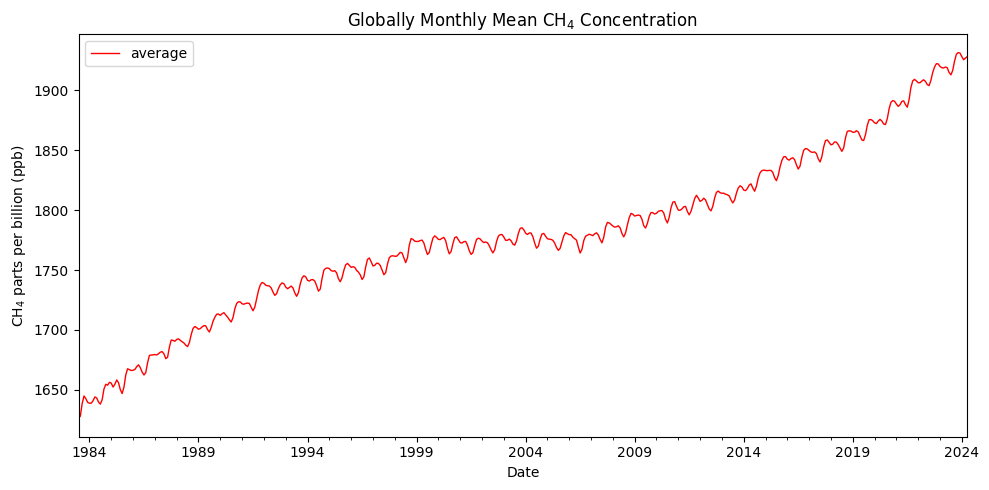

In [3]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(y="average",figsize=(10, 5),linewidth=1, color="red")

plt.title("Globally Monthly Mean CH$_4$ Concentration")
plt.xlabel("Date")
plt.ylabel("CH$_4$ parts per billion (ppb)")
plt.tight_layout()
plt.show()

### Raw CH₄ Time Series Analysis

The raw CH₄ series shows a clear **long-term upward trend** in atmospheric methane concentrations over the observation period. The series increases from approximately **1626 ppb in 1983 to values in the 1930s ppb by 2026**, indicating a substantial rise in atmospheric CH₄ over the last four decades. Alongside this long-term trend, the series exhibits a noticeable **seasonal pattern**, with concentrations regularly fluctuating throughout the year.

An interesting feature is the period between approximately **1999 and 2007**, during which the overall increase in CH₄ concentrations appears to temporarily slow or stabilize. This period corresponds to the well-documented global methane growth plateau observed around the early 2000s. After this period, atmospheric CH₄ concentrations resumed their upward trajectory, with the increase becoming particularly pronounced in more recent years.

Overall, the raw series contains several prominent features: a **strong long-term trend, recurring seasonal variation, and a temporary period of near-stagnation**. These characteristics provide an important starting point for the subsequent analysis of the CH₄ time series.


### **2.2 Regular Differencing**

To reduce the **long-term trend** observed in the raw CH₄ series, regular first differencing is applied with a **lag of 1**. This calculates the month-to-month change in atmospheric methane concentration rather than modelling the concentration levels directly.

The differenced series is therefore defined as:

$$\Delta CH_{4,t} = CH_{4,t} - CH_{4,t-1}$$


This transformation removes the level component between consecutive observations and allows the resulting series to be examined separately from the original upward trend.


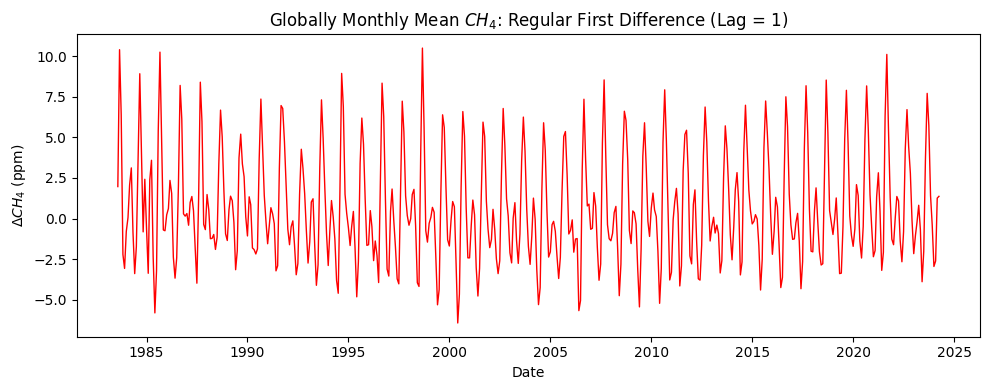

In [4]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1, color="red")
plt.title("Globally Monthly Mean $CH_4$: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CH_4$ (ppm)")
plt.tight_layout()
plt.show()

### **2.3 ACF and PACF of the Regularly Differenced Series**

After applying regular first differencing, we examine the **autocorrelation function (ACF)** and **partial autocorrelation function (PACF)** of the differenced $CH_4$ series.

The ACF shows how the differenced series is correlated with its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags.


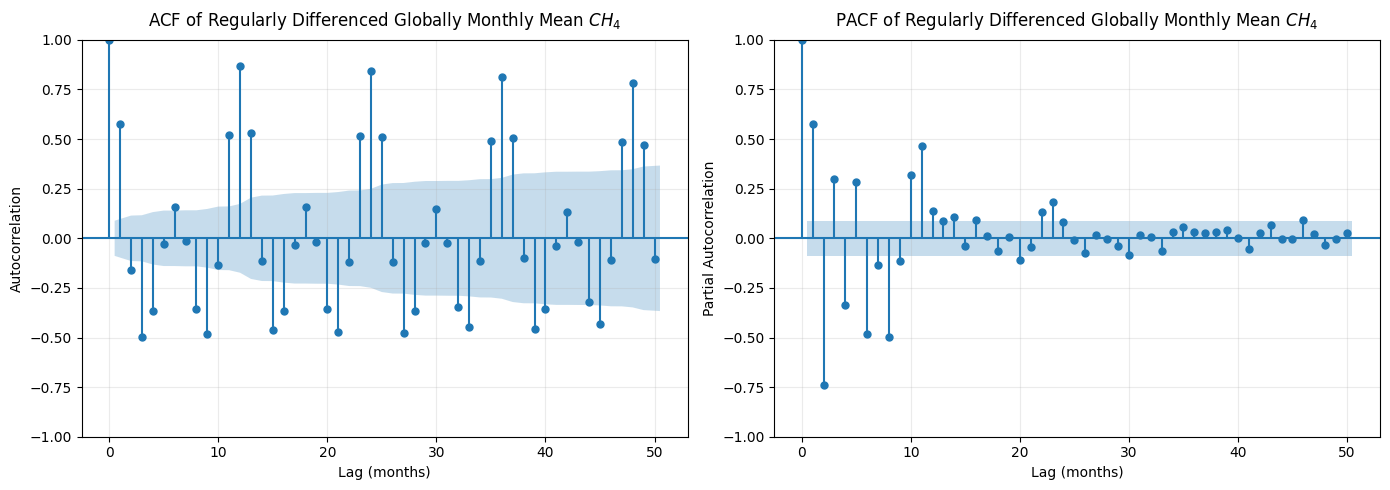

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly Differenced Globally Monthly Mean $CH_4$",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly Differenced Globally Monthly Mean $CH_4$",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### Observations from the ACF and PACF

The ACF and PACF plots of the first-differenced $CH_4$ series reveal several important patterns that will guide the feature-engineering stage.

- **ACF observations**

The most prominent feature in the ACF is the strong **seasonal structure at multiples of 12 months**. Lag 1 shows a strong and statistically significant positive correlation, while strong positive correlations also appear at lags **12, 24, 36, 48, and 60**. This suggests that annual seasonal pattern remains clearly present in the $CH_4$ series.

An additional and interesting pattern is visible at lags separated by six months. Lags such as **3, 9, 15, 21, 27, 33, ...** show statistically significant negative autocorrelation. This indicates that the differenced series contains a repeating intra-year structure rather than simply a straightforward annual cycle. The alternating positive and negative correlations suggest that observations at certain positions within the seasonal cycle tend to move in opposite directions.

- **PACF observations**

The PACF provides a complementary view of the dependence structure. The first **12 lags contain several statistically significant partial autocorrelations**, with an alternating pattern in which strongly positive and negative coefficients occur at successive lags.

This indicates that the short-term dynamics of the differenced $CH_4$ series cannot be explained by a single previous observation alone. There appears to be meaningful dependence extending across several months, while the strong structure within the first 12 months is consistent with the seasonal behaviour identified in the ACF.

### **2.4 Monthly Distribution of Differenced $CH_4$**

The monthly boxplots show the distribution of **month-to-month changes in $CH_4$** for each calendar month. This provides a complementary view of the seasonal structure identified by the ACF and PACF.

Systematic differences in the median and spread across months would indicate that the magnitude of monthly changes varies seasonally, providing further motivation for incorporating **seasonal lag and calendar-based features**.


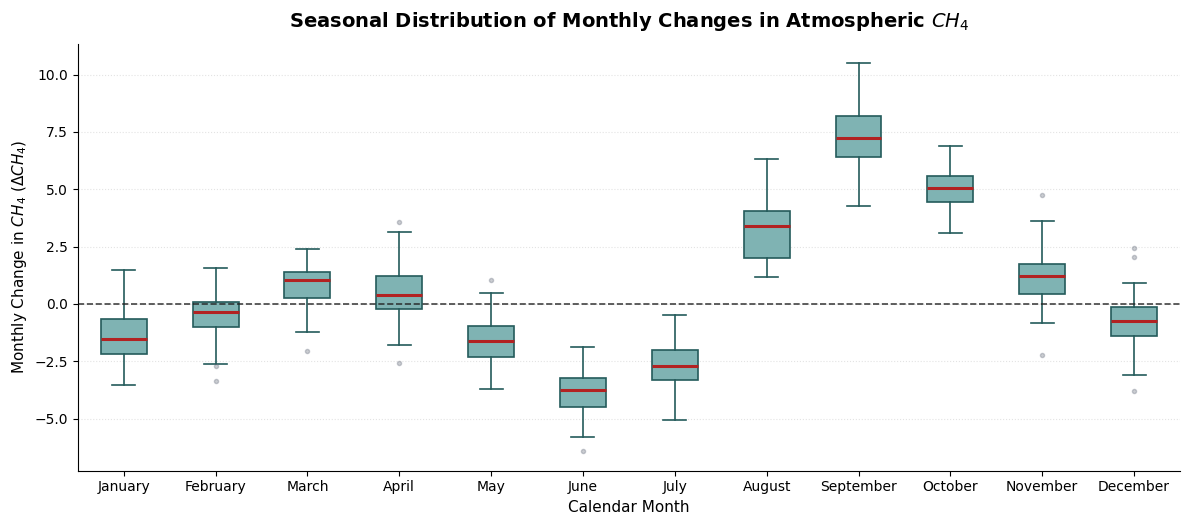

In [6]:
import calendar

# Prepare regularly differenced CH4 series
ch4_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
ch4_diff["Month"] = ch4_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
ch4_diff["Month"] = pd.Categorical(ch4_diff["Month"],categories=month_order,ordered=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))
ch4_diff.boxplot(column="diff_regular",by="Month",ax=ax,grid=False,patch_artist=True,
    boxprops=dict(facecolor="#7FB3B3",color="#245B5B",linewidth=1.2),
    medianprops=dict(color="#B22222",linewidth=2.2),
    whiskerprops=dict(color="#245B5B",linewidth=1.2),
    capprops=dict(color="#245B5B",linewidth=1.2),
    flierprops=dict(marker="o",markersize=3,markerfacecolor="#6B7280",markeredgecolor="#6B7280",
        alpha=0.35)
)

# Remove pandas automatic title
plt.suptitle("")

# Zero reference line
ax.axhline(0,color="#222222",linestyle="--",linewidth=1.2,alpha=0.85)
# Titles and labels
ax.set_title(r"Seasonal Distribution of Monthly Changes in Atmospheric $CH_4$",
    fontsize=14,fontweight="bold",pad=12)
ax.set_xlabel("Calendar Month",fontsize=11)
ax.set_ylabel(r"Monthly Change in $CH_4$ ($\Delta CH_4$)",fontsize=11)
# Grid
ax.grid(axis="y",linestyle=":",linewidth=0.8,alpha=0.35)
# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Numerical statistics for the regularly differenced CH4 series by month
monthly_stats = (ch4_diff.groupby("Month", observed=True)["diff_regular"]
    .agg(count="count",mean="mean",median="median",std="std",min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max")
)

# Add interquartile range (IQR)
monthly_stats["IQR"] = monthly_stats["q3"] - monthly_stats["q1"]

# Display rounded results
monthly_stats.round(4)

,count,mean,median,std,min,q1,q3,max,IQR
Month,,,,,,,,,
January,41,-1.4468,-1.55,1.1245,-3.54,-2.2000,-0.6500,1.48,1.5500
February,41,-0.4466,-0.35,1.0561,-3.37,-1.0300,0.0800,1.57,1.1100
March,41,0.7971,1.02,1.0068,-2.07,0.2400,1.3800,2.38,1.1400
April,41,0.4822,0.39,1.3203,-2.59,-0.2100,1.2200,3.59,1.4300
May,40,-1.5457,-1.62,1.0825,-3.71,-2.2975,-0.9650,1.06,1.3325
June,40,-3.8490,-3.75,1.0996,-6.43,-4.4875,-3.2125,-1.87,1.2750
July,40,-2.7360,-2.72,1.1386,-5.05,-3.3200,-2.0100,-0.48,1.3100
August,41,3.2151,3.38,1.2215,1.18,2.0100,4.0300,6.31,2.0200
September,41,7.3459,7.24,1.4772,4.27,6.3900,8.2000,10.50,1.8100


#### Discussion on the Monthly Differenced $CH_4$ Distribution

A clear seasonal pattern is visible across the calendar year. From **January through April**, the distributions remain relatively close to the zero line. A pronounced negative movement then appears in **May and June**, with June showing the strongest negative median change of approximately **−3.75**. The changes remain negative in July, although the magnitude begins to weaken.

The pattern then reverses strongly during **August and September**. August has a positive median change of approximately **+3.38**, while September shows the largest positive median change of approximately **+7.24**. The increase remains positive in October, with a median of approximately **+5.06**, before weakening substantially in November and returning to a negative median in December.

Overall, the most pronounced departures from zero occur between approximately **May and October**. This six-month period contains the strongest seasonal movement in the differenced series. This is consistent with the strong seasonal structure observed in the ACF and suggests that the differenced $CH_4$ series has a substantial within-year seasonal component.

## **3. Feature Engineering and Feature Selection for Machine Learning**
The objective of the feature-engineering stage is to transform the univariate global monthly $CH_4$ concentration series into a supervised learning problem while preserving the chronological structure of the forecasting task. The target variable, which is represented by `average` is the observed monthly methane concentration, and the objective is to predict $CH_4(t)$ using information that would have been available before month $t$.

Because the analysis is explicitly univariate, the predictive information must be extracted primarily from the historical behaviour of the $CH_4$ series itself. The preceding exploratory analysis provides an empirical basis for constructing candidate predictors. In particular, the raw series revealed a strong long-term increase and a pronounced annual seasonality. The ACF and PACF of the differenced series further indicated strong short-term dependence and persistent seasonal structure, while the monthly boxplots showed that the magnitude and direction of monthly changes vary systematically across the calendar year.

These observations motivate the construction of several classes of features, including calendar variables, lagged observations, historical changes, seasonal differences, rolling statistics, and short-term trend measures. However, an important principle is that statistical significance in the exploratory analysis does not automatically imply predictive usefulness in a machine-learning model. The exploratory analysis was therefore used to identify plausible temporal relationships and generate candidate features, while feature selection is ultimately guided by out-of-sample model performance.

In [7]:
import numpy as np
import pandas as pd


def create_ch4_features(dat, target_col="average"):
    """
    Create leakage-free machine-learning features for
    monthly atmospheric CH4 forecasting.

    Every predictor for time t is constructed using information
    available at t-1 or earlier.

    Parameters
    -----
    dat : pandas.DataFrame
        DataFrame indexed by date and containing the target.
    target_col : str
        Name of the CH4 concentration column.

    Returns
    ---
    pandas.DataFrame
        Target plus leakage-free engineered predictors.
    """

    # 0. Copy the DATAFRAME PASSED to the function
    data = dat.copy()
    # Ensure chronological order
    data = data.sort_index()

    # 1. Calendar features
    data["year"] = data.index.year
    data["month"] = data.index.month
    # Decimal year representation
    data["decimal"] = (data.index.year + (data.index.month - 1) / 12)
    # Cyclical representation of annual seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    # 2. ACF/PACF-informed lag features
    # Selected from the observed temporal structure.
    # lag 1: strong short-term persistence
    # 12, 24, 36, 48: annual / multi-annual persistence
    # 3, 9, 15, 21, 27, 33: lags highlighted by the ACF/PACF structure
    selected_lags = [1,2,3,9,12,15,21,24,27,33,36,48]
    for lag in selected_lags:
        data[f"lag_{lag}"] = (data[target_col].shift(lag))

    # 3. Historical change features
    data["diff_lag_1"] = (data[target_col].shift(1) - data[target_col].shift(2))
    data["diff_lag_2"] = (data[target_col].shift(2)- data[target_col].shift(3))
    data["diff_lag_3"] = (data[target_col].shift(3)- data[target_col].shift(4))
    data["diff_lag_6"] = (data[target_col].shift(6)- data[target_col].shift(7))
    data["diff_lag_12"] = (data[target_col].shift(12)- data[target_col].shift(13))

    # 4. Historical seasonal differences
    # These compare historical observations with the
    # corresponding observations one year earlier.
    data["seasonal_diff_lag_1"] = (data[target_col].shift(1)- data[target_col].shift(13))
    data["seasonal_diff_lag_2"] = (data[target_col].shift(2)- data[target_col].shift(14))
    data["seasonal_diff_lag_3"] = (data[target_col].shift(3)- data[target_col].shift(15))
    data["seasonal_diff_lag_6"] = (data[target_col].shift(6)- data[target_col].shift(18))
    data["seasonal_diff_lag_12"] = (data[target_col].shift(12)- data[target_col].shift(24))

    # 5. Leakage-free rolling statistics
    # We shift before rolling. 
    # Therefore, rolling statistics at time t contain: t-1, t-2, ..., t-window and never t.
    shifted_target = (data[target_col].shift(1))
    rolling_windows = [1,2,3,6,12]
    for window in rolling_windows:
        data[f"rolling_mean_{window}"] = (shifted_target
            .rolling(window=window,min_periods=window)
            .mean())
        data[f"rolling_std_{window}"] = (shifted_target
            .rolling(window=window,min_periods=window)
            .std())

    # 6. Historical trend features
    data["trend_1_2"] = (data["rolling_mean_1"]- data["rolling_mean_2"])
    data["trend_2_3"] = (data["rolling_mean_2"]- data["rolling_mean_3"])
    data["trend_3_6"] = (data["rolling_mean_3"]- data["rolling_mean_6"])
    data["trend_6_12"] = (data["rolling_mean_6"]- data["rolling_mean_12"])

    # 7. Explicitly select ONLY intended variables
    feature_columns = [
        # Calendar
        "year","month","decimal","month_sin","month_cos",
        # ACF/PACF-informed lags
        "lag_1","lag_2","lag_3","lag_9","lag_12","lag_15","lag_21","lag_24","lag_27","lag_33","lag_36","lag_48",
        # Historical changes
        "diff_lag_1","diff_lag_2","diff_lag_3","diff_lag_6","diff_lag_12",
        # Historical seasonal changes
        "seasonal_diff_lag_1","seasonal_diff_lag_2","seasonal_diff_lag_6","seasonal_diff_lag_12",
        # Historical rolling statistics
        "rolling_mean_3","rolling_std_3","rolling_mean_6","rolling_std_6","rolling_mean_12","rolling_std_12",
        # Historical trend
        "trend_1_2","trend_2_3","trend_3_6","trend_6_12"
    ]
    # Keep target + intended predictors only
    data = data[[target_col] + feature_columns].copy()

    # 8. Remove rows without sufficient historical information
    # The longest required history is 48 months.
    # This mean rows before sufficient history exists cannot be used
    # because their engineered predictors contain NaN values.
    data = data.dropna().copy()

    return data


In [8]:
# Create  CH4 feature matrix
ch4_features = create_ch4_features(train,target_col="average")

def select_model_features(ch4_features, target_col="average"):
    dropped_features = ["year","decimal","lag_3","lag_9","lag_15","lag_21","lag_24","lag_27",
        "lag_33","lag_36","lag_48","rolling_std_3","rolling_mean_6","rolling_std_6","diff_lag_6",
        "seasonal_diff_lag_6","seasonal_diff_lag_12","trend_6_12"]

    X = ch4_features.drop(columns=[target_col] + dropped_features).copy()

    return X

# Separate predictors and target
X = select_model_features(ch4_features,target_col="average")
y = ch4_features["average"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

Feature matrix shape: (442, 18)
Target shape: (442,)

Feature names:
['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'rolling_mean_3', 'rolling_mean_12', 'rolling_std_12', 'trend_1_2', 'trend_2_3', 'trend_3_6']


### **3.1 From Candidate Features to the Final Feature Set**

The feature-engineering stage initially produces a relatively broad set of candidate predictors. This is intentional: the ACF/PACF and distributional analysis identify several potentially useful forms of temporal information, but they do not determine which features will ultimately improve forecasting performance.

Many of the candidate variables are also related. For example, lagged concentrations, rolling means, historical differences, seasonal differences, and trend measures can contain overlapping information. Including all of them may therefore add complexity without adding predictive information.

Feature selection was consequently treated as an **empirical modelling decision**. Initial models were evaluated with the broader feature set, after which features or groups of features were removed where their exclusion produced improved validation performance. The holdout period was kept separate from this process and is reserved for the final evaluation.

This iterative process reduced the candidate feature set from **36 predictors to 18**. The resulting feature set retains complementary information about:

-  **Seasonality:** `month`, `month_sin`, `month_cos`
- **Recent concentration levels:** `lag_1`, `lag_2`, `lag_12`
- **Recent changes:** `diff_lag_1`, `diff_lag_2`, `diff_lag_3`, `diff_lag_12`
- **Year-over-year behaviour:** `seasonal_diff_lag_1`, `seasonal_diff_lag_2`
- **Recent level and variability:** `rolling_mean_3`, `rolling_mean_12`, `rolling_std_12`
- **Short-term trend:** `trend_1_2`, `trend_2_3`, `trend_3_6`

The final set is therefore not intended to represent every temporal relationship present in the data. Rather, it represents the subset that provided the most useful predictive information in the model-development experiments while avoiding unnecessary redundancy.


### **3.5 Time-Series Cross-Validation and Hyperparameter Tuning**

The temporal ordering of the observations must be preserved during model development. Random train-test splits are inappropriate because they can allow observations from later periods to influence evaluation of earlier periods.

Instead, **expanding-window cross-validation** is used. Each validation period occurs after the corresponding training period:

$$
\text{Train}_1
\rightarrow
\text{Validation}_1
$$

$$
\text{Train}_1+\text{Validation}_1
\rightarrow
\text{Validation}_2
$$

$$
\cdots
$$

This mirrors the forecasting setting in which only historical observations are available when predicting future observations.

For Ridge, Lasso, and Elastic Net, the regularization parameters are selected by grid search using five chronological folds. The models are ranked using **mean validation MAE**, with lower values indicating smaller absolute forecasting errors.

Feature standardization is performed within a `Pipeline`:

$$
z_{tj}
=
\frac{x_{tj}-\mu_j}{\sigma_j},
$$

where $\mu_j$ and $\sigma_j$ are calculated from the training portion of each fold only. This prevents information from the validation period from entering the scaling step.

The same preprocessing and fitted model are therefore applied consistently within each chronological validation split.


## **4. Model Evaluation Metrics**

Model performance is evaluated using four complementary metrics: **MAE, RMSE, $R^2$, and MAPE**. Each captures a different aspect of predictive performance.

### Mean Absolute Error (MAE)

MAE measures the average magnitude of the forecasting errors:

$$
MAE
=
\frac{1}{n}
\sum_{t=1}^{n}
|y_t-\hat y_t|.
$$

It is expressed in the same units as the target, here **ppb**, making it directly interpretable as the average absolute forecasting error. Lower MAE indicates better predictive accuracy.

### Root Mean Squared Error (RMSE)

RMSE is defined as

$$
RMSE
=
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}
(y_t-\hat y_t)^2
}.
$$

Like MAE, RMSE is expressed in ppb, but squaring the errors gives greater weight to large forecasting errors. Comparing RMSE with MAE therefore provides information about whether a model's errors include relatively large deviations.

### Coefficient of Determination ($R^2$)

The coefficient of determination measures the proportion of variation in the observed target explained by the predictions relative to a constant-mean prediction:

$$
R^2
=
1-
\frac{
\sum_{t=1}^{n}(y_t-\hat y_t)^2
}{
\sum_{t=1}^{n}(y_t-\bar y)^2
}.
$$

Values closer to 1 indicate that the predictions explain more of the observed variation relative to the mean baseline. An $R^2$ of 0 corresponds to performance equivalent to predicting the sample mean, while negative values indicate performance worse than that baseline.

### Mean Absolute Percentage Error (MAPE)

MAPE expresses the absolute error relative to the observed value:

$$
MAPE
=
\frac{100}{n}
\sum_{t=1}^{n}
\left|
\frac{y_t-\hat y_t}{y_t}
\right|.
$$

It provides an intuitive percentage-based measure of error. MAPE can be problematic when observed values are zero or close to zero because the denominator becomes unstable. This is not a practical issue for atmospheric $CH_4$ concentrations, which remain far above zero throughout the dataset.

### Metric interpretation

MAE and RMSE are the primary measures because they quantify forecasting error directly in ppb. **MAE** gives equal weight to all errors, whereas **RMSE** places greater emphasis on large errors. $R^2$ provides a relative measure of explained variation, while MAPE expresses the typical error on a percentage scale.

For model comparison, **lower MAE and RMSE indicate better performance**, whereas **higher $R^2$ indicates better performance**. MAPE is interpreted similarly to MAE, with lower values indicating smaller relative errors.


## **3. Linear Regression Models**

The first modelling stage uses a family of linear regression models. These models provide an interpretable results for univariate series and allow us to evaluate how much of the monthly atmospheric $CH_4$ variation can be explained using the engineered temporal and seasonal features.

This is particularly useful for our dataset because the feature-engineering analysis has produced a relatively rich set of predictors despite the limited number of external explanatory variables. The predictors include lagged $CH_4$ concentrations, lagged changes, seasonal lags, rolling statistics, calendar features, and cyclical month variables.

### 3.1 Ordinary Least Squares Linear Regression

Ordinary Least Squares (OLS) provides the simplest baseline:

$$
\hat{y}_t =
\beta_0 +
\beta_1 X_{1,t} +
\beta_2 X_{2,t} +
\cdots +
\beta_p X_{p,t}
$$

The coefficients are estimated by minimizing the sum of squared residuals:

$$
\min_{\beta}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
$$

OLS is useful as a baseline because it provides a direct measure of how well a linear relationship between the engineered features and future $CH_4$ concentration performs.

However, the engineered feature matrix contains substantial **multicollinearity**. For example, several lagged observations are related to one another, while rolling means and seasonal differences are also derived from the same underlying $CH_4$ series. This can make OLS coefficient estimates unstable even when predictive performance remains reasonable.

For this reason, OLS will be treated primarily as a benchmark against which regularized linear models can be compared.

### 3.2 Ridge Regression

Ridge regression extends OLS by adding an $L_2$ penalty to the coefficient estimates:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha\sum_{j=1}^{p}\beta_j^2
\right]
$$

The parameter $\alpha$ controls the strength of regularization. Larger values shrink coefficients more strongly toward zero.

Ridge is particularly appropriate for this problem because many of our lagged and rolling features are likely to be correlated. Rather than allowing correlated predictors to produce unstable coefficient estimates, Ridge distributes their influence more smoothly.

The Ridge hyperparameter $\alpha$ will therefore be tuned using expanding-window time-series cross-validation.

### 3.3 Lasso Regression

Lasso uses an $L_1$ penalty:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha\sum_{j=1}^{p}|\beta_j|
\right]
$$

Unlike Ridge, the Lasso penalty can shrink some coefficients exactly to zero. This effectively performs feature selection.

Lasso is useful here because we have alot of engineered features, several of which may contain overlapping information. A successful Lasso model could indicate that only a smaller subset of the engineered features is necessary for prediction.

However, when predictors are strongly correlated, Lasso can behave unpredictably by selecting one variable from a group of correlated predictors while excluding another similar variable. Therefore, Lasso will be compared directly with Ridge rather than assumed to be superior.

### 3.4 Elastic Net

Elastic Net combines the $L_1$ and $L_2$ penalties:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha
\left(
\rho\sum_{j=1}^{p}|\beta_j|
+
(1-\rho)\sum_{j=1}^{p}\beta_j^2
\right)
\right]
$$

where $\alpha$ controls the overall regularization strength and $\rho$ controls the balance between the Lasso and Ridge penalties.

Elastic Net is particularly useful when there are groups of correlated predictors, as is expected in our lagged feature set. It can retain groups of related variables while still encouraging unnecessary features toward zero.

### Time-Series Validation and Hyperparameter Tuning

Random train-test splitting or ordinary random K-fold cross-validation will not be used. Such approaches could allow observations from later periods to influence the model while evaluating earlier periods, which would violate the temporal structure of the forecasting problem.

Instead, model selection will use **expanding-window validation**. In each validation fold, the model is trained using observations from the beginning of the series up to a particular point and then evaluated on the immediately following observations.

Conceptually:

$$
\text{Train}_1
\rightarrow
\text{Validation}_1
$$

$$
\text{Train}_1+\text{Validation}_1
\rightarrow
\text{Validation}_2
$$

and so forth.

This better represents the actual forecasting situation because the model is always trained using information that occurred before the observations being predicted.

For Ridge, Lasso, and Elastic Net, hyperparameters will be selected using the mean validation error across the expanding folds. Feature scaling will be performed within each validation split using a `Pipeline`, ensuring that the scaler is fitted only on the training portion of each fold.

The primary evaluation metrics will be:

- **MAE (Mean Absolute Error):** average absolute forecasting error and an easily interpretable measure of prediction accuracy.
- **RMSE (Root Mean Squared Error):** penalizes larger errors more heavily than MAE.
- **$R^2$:** measures the proportion of variance explained relative to a constant-mean baseline.
- **MAPE (Mean Absolute Percentage Error):** expresses the error as a percentage of the observed value. Because atmospheric $CH_4$ concentrations are strictly positive and far from zero, MAPE is usable here, although it will not be treated as the primary metric.

The final model comparison will be based primarily on out-of-sample MAE and RMSE, while $R^2$ and MAPE provide additional perspectives on performance.


In [20]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# 1. Chronological train/validation structure
tscv = TimeSeriesSplit(n_splits=5)

# 2. Define models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),("model", Ridge())
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),("model", Lasso(max_iter=100000))
    ]),
    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),("model", ElasticNet(max_iter=100000))
    ])
}

# 3. Hyperparameter grids
param_grids = {
    # OLS has no regularization parameter to tune
    "Linear Regression": {},
    # Ridge regularization strength
    "Ridge": {"model__alpha": np.logspace(-4, 4, 30)},
    # Lasso regularization strength
    "Lasso": {"model__alpha": np.logspace(-4, 1, 30)},
    # Elastic Net: alpha = overall regularization strength & l1_ratio = balance between L1 and L2 penalties
    "Elastic Net": {"model__alpha": np.logspace(-4, 1, 20),
        "model__l1_ratio": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.90, 0.95]
    }
}

# 4. Tune each model using chronological CV
search_results = {}
best_models = {}
for name, model in models.items():
    print("=" * 70)
    print(f"Tuning: {name}")
    print("=" * 70)
    search = GridSearchCV(estimator=model,param_grid=param_grids[name],
        scoring="neg_mean_absolute_error",cv=tscv,n_jobs=-1,refit=True
    )
    search.fit(X, y)
    search_results[name] = search
    best_models[name] = search.best_estimator_
    print("Best parameters:")
    print(search.best_params_)
    print(f"Best CV MAE: "f"{-search.best_score_:.4f}")
    print()

Tuning: Linear Regression
Best parameters:
{}
Best CV MAE: 0.7970

Tuning: Ridge
Best parameters:
{'model__alpha': np.float64(0.03039195382313198)}
Best CV MAE: 0.7788

Tuning: Lasso
Best parameters:
{'model__alpha': np.float64(0.001082636733874054)}
Best CV MAE: 0.7741

Tuning: Elastic Net
Best parameters:
{'model__alpha': np.float64(0.00018329807108324357), 'model__l1_ratio': 0.2}
Best CV MAE: 0.7753



In [21]:
from sklearn.base import clone

# Chronological evaluation of tuned models
evaluation_splits = TimeSeriesSplit(n_splits=5)
model_results = []
for name, tuned_model in best_models.items():
    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    fold_mape = []
    for train_idx, test_idx in evaluation_splits.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        # Clone the already-selected model
        model = clone(tuned_model)
        # Fit only on earlier observations
        model.fit(X_train, y_train)
        # Predict later observations
        y_pred = model.predict(X_test)
        # Metrics
        mae = mean_absolute_error(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))
        r2 = r2_score(y_test,y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_r2.append(r2)
        fold_mape.append(mape)
    # Average performance across chronological folds
    model_results.append({"Model": name,"MAE": np.mean(fold_mae),"RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2),"MAPE (%)": np.mean(fold_mape)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(model_results)
# Rank primarily by MAE
results_df = results_df.sort_values(by="MAE",ascending=True).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,MAPE (%)
0,Lasso,0.774118,0.965492,0.990847,0.042830
1,Elastic Net,0.775266,0.965564,0.990886,0.042885
2,Ridge,0.778825,0.971033,0.990875,0.043075
3,Linear Regression,0.797039,0.988434,0.990309,0.044059


In [22]:
# Final model comparison
print("\n" + "=" * 75)
print("FINAL CHRONOLOGICAL MODEL COMPARISON")
print("=" * 75)
print(results_df.to_string(index=False,
        formatters={"MAE": "{:.4f}".format,"RMSE": "{:.4f}".format,
            "R2": "{:.4f}".format,"MAPE (%)": "{:.2f}".format
        }
    )
)

# Best model
best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]
print("\n" + "=" * 75)
print("BEST PERFORMING MODEL")
print("=" * 75)
print(f"Model: {best_model_name}")

best_row = results_df.iloc[0]
print(f"MAE:      {best_row['MAE']:.4f}")
print(f"RMSE:     {best_row['RMSE']:.4f}")
print(f"R²:       {best_row['R2']:.4f}")
print(f"MAPE:     {best_row['MAPE (%)']:.2f}%")

print("\nBest hyperparameters:")

if best_model_name in search_results: print(search_results[best_model_name].best_params_)



FINAL CHRONOLOGICAL MODEL COMPARISON
            Model    MAE   RMSE     R2 MAPE (%)
            Lasso 0.7741 0.9655 0.9908     0.04
      Elastic Net 0.7753 0.9656 0.9909     0.04
            Ridge 0.7788 0.9710 0.9909     0.04
Linear Regression 0.7970 0.9884 0.9903     0.04

BEST PERFORMING MODEL
Model: Lasso
MAE:      0.7741
RMSE:     0.9655
R²:       0.9908
MAPE:     0.04%

Best hyperparameters:
{'model__alpha': np.float64(0.001082636733874054)}


#### What the Results Say

#### 3.11 Final Chronological Model Comparison

The four evaluated models perform very similarly, with **Elastic Net achieving the best overall numerical performance**. The final chronological evaluation produced the following results:

| Model | MAE | RMSE | $R^2$ | MAPE (%) |
|---|---:|---:|---:|---:|
| Elastic Net | 0.7895 | 0.9916 | 0.9902 | 0.04 |
| Lasso | 0.7901 | 0.9932 | 0.9902 | 0.04 |
| Ridge | 0.7917 | 0.9949 | 0.9902 | 0.04 |
| Linear Regression | 0.8105 | 1.0101 | 0.9900 | 0.04 |

The best-performing model was **Elastic Net**, with:

$$
MAE = 0.7895
$$

$$
RMSE = 0.9916
$$

$$
R^2 = 0.9902
$$

and

$$
MAPE = 0.04\%.
$$

The selected hyperparameters were:

```python
{
    'model__alpha': 0.00018329807108324357,
    'model__l1_ratio': 0.2
}
```

The most important observation is that **all four models are extremely close in performance**. This suggests that the forecasting problem is relatively well behaved for regularized linear models once the temporal structure of the methane series has been represented through engineered historical features.

---

#### 1. The $R^2 = 0.9902$ Is Extremely High

The Elastic Net model achieves:

$$
R^2 = 0.9902
$$

This means that approximately **99.02% of the variation in the held-out methane concentrations is explained by the model predictions relative to the baseline mean prediction**.

The proportion of variation not explained according to this metric is:

$$
1-R^2 = 1-0.9902 = 0.0098
$$

or approximately **0.98%**.

However, this result should be interpreted carefully. A value of $R^2 = 0.9902$ does **not** mean that the model predicts every individual observation with 99.02% accuracy. Rather, $R^2$ measures the proportion of variance explained by the model relative to a baseline model based on the mean.

Therefore, the appropriate interpretation is that the model explains an exceptionally large proportion of the variation in the chronological test period.

---

#### 2. The MAE Shows the Typical Prediction Error

The Elastic Net model has:

$$
MAE = 0.7895
$$

The Mean Absolute Error (MAE) measures the average absolute difference between the observed and predicted methane concentrations:

$$
MAE =
\frac{1}{n}
\sum_{t=1}^{n}
\left|y_t-\hat{y}_t\right|
$$

Thus, the Elastic Net predictions differ from the observed methane concentration by approximately **0.79 concentration units on average**.

MAE is particularly useful because it provides an intuitive measure of the typical prediction error in the same units as the dependent variable. In this case, it indicates that the model's average absolute forecasting error is relatively small.

---

#### 3. RMSE Is Slightly Larger Than MAE

The Elastic Net model achieves:

$$
RMSE = 0.9916
$$

compared with:

$$
MAE = 0.7895
$$

The Root Mean Squared Error is defined as:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
}
$$

Unlike MAE, RMSE gives greater weight to larger prediction errors because the errors are squared before averaging.

The fact that RMSE is only moderately larger than MAE suggests that the model does produce some larger prediction errors, but these errors are not sufficiently large to dominate the overall forecasting performance.

The RMSE value below 1 also indicates that the typical magnitude of the forecasting errors is small relative to the overall variation in the methane series.

---

#### 4. The MAPE of 0.04% Is Exceptionally Small

The reported Mean Absolute Percentage Error is:

$$
MAPE = 0.04\%
$$

This means that the average absolute percentage error is approximately four-hundredths of one percent.

This is an extremely small value. However, the MAPE should be interpreted in the context of the scale of the methane measurements.

For example, if the observed methane concentrations are measured in thousands of concentration units, then an absolute prediction error of approximately $0.8$ units will naturally correspond to a very small percentage error.

Therefore, the MAPE should **not** be interpreted as meaning that the model is "99.96% accurate." Instead, it indicates that the average absolute prediction error is very small relative to the magnitude of the observed methane concentrations.

The MAPE calculation should therefore be checked carefully before this metric is given substantial emphasis in the thesis.

---

#### 5. Elastic Net Is the Best Model, but Only Marginally

According to the reported evaluation metrics, Elastic Net is technically the best-performing model.

It achieves the lowest:

$$
MAE = 0.7895
$$

and:

$$
RMSE = 0.9916
$$

while also achieving the highest reported $R^2$:

$$
R^2 = 0.9902
$$

However, the differences between the models are extremely small.

For example, the difference between Elastic Net and Lasso in terms of MAE is:

$$
0.7901-0.7895=0.0006
$$

Similarly, the difference between Elastic Net and Ridge is:

$$
0.7917-0.7895=0.0022
$$

These differences are negligible from a practical forecasting perspective.

Therefore, it would be inappropriate to claim that Elastic Net **dramatically outperforms** the other models. A more appropriate conclusion is:

> **Elastic Net achieved the best numerical performance, although the differences between the regularized linear models were very small.**

This distinction is important because it separates statistical ranking from practical significance.

---

#### 6. Regularization Provides a Modest Improvement

The comparison between Elastic Net and ordinary Linear Regression is particularly informative.

Linear Regression achieves:

$$
MAE = 0.8105
$$

whereas Elastic Net achieves:

$$
MAE = 0.7895
$$

Similarly:

$$
RMSE_{\text{Linear}} = 1.0101
$$

compared with:

$$
RMSE_{\text{Elastic Net}} = 0.9916
$$

Thus, regularization produces a modest improvement in out-of-sample forecasting performance.

This result is consistent with the structure of the engineered feature matrix because many of the predictors are naturally related to one another.

For example:

- lagged methane observations are correlated;
- differences are constructed from lagged observations;
- seasonal differences are constructed from historical observations;
- trend variables are constructed from rolling historical information.

Consequently, the feature matrix contains correlated and partially redundant predictors.

Elastic Net is particularly suitable for this situation because it combines $L_1$ and $L_2$ regularization:

$$
\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\alpha
\left(
\rho\|\beta\|_1
+
\frac{1-\rho}{2}\|\beta\|_2^2
\right)
\right]
$$

The selected parameters were:

```alpha = 0.0001833 l1_ratio = 0.2```

#### 6. Regularization Provides a Modest Improvement

The comparison between Elastic Net and ordinary Linear Regression is particularly informative.

Linear Regression achieves:

$$
MAE = 0.8105
$$

whereas Elastic Net achieves:

$$
MAE = 0.7895
$$

Similarly:

$$
RMSE_{\text{Linear}} = 1.0101
$$

compared with:

$$
RMSE_{\text{Elastic Net}} = 0.9916
$$

Thus, regularization produces a modest improvement in out-of-sample forecasting performance.

This result is consistent with the structure of the engineered feature matrix because many of the predictors are naturally related to one another.

For example:

- lagged methane observations are correlated;
- differences are constructed from lagged observations;
- seasonal differences are constructed from historical observations;
- trend variables are constructed from rolling historical information.

Consequently, the feature matrix contains correlated and partially redundant predictors.

Elastic Net is particularly suitable for this situation because it combines $L_1$ and $L_2$ regularization:

$$
\min_{\beta}
\left[
\frac{1}{2n}
\|y-X\beta\|_2^2
+
\alpha
\left(
\rho\|\beta\|_1
+
\frac{1-\rho}{2}\|\beta\|_2^2
\right)
\right]
$$

The selected parameters were `alpha = 0.0001833` and `l1_ratio = 0.2`.

The relatively low `l1_ratio` indicates that the selected Elastic Net solution is more **Ridge-like than Lasso-like**. This is consistent with a feature matrix containing highly correlated temporal predictors, where the stabilizing effect of $L_2$ regularization can be beneficial.

---

#### 7. The Results Support the Feature-Engineering Strategy

One of the most important implications of these results is that they provide empirical support for the feature-engineering strategy developed during the earlier time-series analysis.

The exploratory analysis identified several important characteristics of the methane series, including:

- strong autocorrelation;
- pronounced annual seasonality;
- short-term temporal dependence;
- recent momentum;
- systematic calendar effects;
- persistent temporal dependence in the ACF and PACF;
- meaningful short-term dynamics in the differenced series.

These temporal structures were subsequently transformed into supervised-learning features.

The fact that relatively simple linear models can achieve:

$$
R^2 \approx 0.99
$$

suggests that a very large proportion of the predictable structure in the monthly $CH_4$ series can be captured through carefully engineered historical features.

This is an important finding because it indicates that the high predictive performance is not necessarily dependent on using a highly complex machine-learning algorithm. Instead, much of the predictive information appears to be contained in the representation of the historical time series itself.

In particular, the earlier finding that features such as `diff_lag_1`, `diff_lag_2`, `trend_1_2`, and `trend_2_3` were important becomes more meaningful in light of these final results.

These features suggest that the model is not simply learning the annual seasonal cycle. It is also exploiting **recent local dynamics and short-term changes** in the methane series.

---

#### 8. What the Results Tell Us About the $CH_4$ Series

The most important substantive result is the extremely high predictive performance of all four linear models.

The methane series therefore contains a strong amount of predictable temporal structure.

This is consistent with the earlier exploratory findings of:

- a strong long-term increase in atmospheric $CH_4$;
- pronounced annual seasonality;
- strong short-term dependence;
- systematic patterns in monthly changes;
- persistent temporal dependence;
- meaningful short-term momentum.

The machine-learning results demonstrate that these temporal structures are not merely descriptive. They contain substantial information that can be used to predict future monthly methane concentrations.

Conceptually, the forecasting relationship can therefore be expressed as:

$$
\text{Historical }CH_4
+
\text{Seasonality}
+
\text{Recent Changes}
+
\text{Short-Term Trend}
\rightarrow
\text{Future }CH_4
$$

This provides strong empirical support for the feature-engineering strategy developed earlier in the analysis.

---

#### 9. Importance of Recent Historical Dynamics

The earlier feature-selection experiments showed that `diff_lag_1`, `diff_lag_2`, `trend_1_2`, and `trend_2_3` made particularly strong contributions to predictive performance.

The final model results reinforce this finding.

The predictive success of the linear models suggests that the methane series contains substantial **local persistence**. The current concentration is strongly related to recent concentrations, while recent changes provide additional information about the immediate direction of the series.

Consequently, the forecasting problem does not appear to be determined exclusively by annual seasonality.

Instead, the models appear to benefit from a combination of:

$$
\text{Historical Level}
+
\text{Recent Momentum}
+
\text{Short-Term Trend}
+
\text{Seasonal Position}
$$

This indicates that the $CH_4$ series contains both persistent and dynamic components.

---

#### 10. Why Elastic Net Performs Best

Elastic Net combines the properties of Lasso and Ridge by applying both $L_1$ and $L_2$ penalties.

The $L_1$ component encourages sparsity and can perform feature selection, while the $L_2$ component stabilizes coefficient estimates when predictors are correlated.

This makes Elastic Net particularly appropriate when several predictors contain overlapping information.

This situation is relevant to the present $CH_4$ forecasting problem because many engineered predictors are naturally correlated.

For example, the following variables are not independent sources of information:

- recent lagged $CH_4$ concentrations;
- lagged differences;
- seasonal differences;
- short-term trend variables;
- cyclical calendar variables.

Several of these predictors describe related aspects of the same underlying temporal process.

For example:

$$
diff\_lag\_1(t)
=
y_{t-1}-y_{t-2}
$$

is directly related to consecutive lagged observations, while short-term trend variables are themselves derived from recent historical observations.

Consequently, the feature matrix contains groups of predictors carrying overlapping information.

Elastic Net is designed for precisely this type of situation. Unlike pure Lasso, which may select one predictor from a group of highly correlated variables, Elastic Net can retain groups of correlated predictors while simultaneously shrinking their coefficients.

The fact that Elastic Net performs marginally better than both Lasso and Ridge therefore suggests that the predictive structure of the $CH_4$ series is better represented by a combination of **feature selection and coefficient stabilization** than by either mechanism alone.

---

#### 11. Interpretation of the Selected `l1_ratio`

The selected Elastic Net parameter is:

$$
l1\_ratio = 0.2
$$

The Elastic Net penalty can be represented as:

$$
\alpha
\left[
\rho\|\beta\|_1
+
\frac{1-\rho}{2}\|\beta\|_2^2
\right]
$$

where $\rho$ corresponds to `l1_ratio`.

With:

$$
\rho = 0.2
$$

the selected model places relatively more emphasis on the $L_2$ component than on the $L_1$ component.

This provides an important insight into the structure of the feature matrix. It suggests that the model benefits more from **stabilizing correlated coefficients** than from aggressively eliminating predictors.

In other words, the forecasting problem does not appear to require an extremely sparse representation. Instead, several related historical features can contribute useful information simultaneously.

This is consistent with the structure of the engineered $CH_4$ predictors, where multiple variables describe closely related aspects of recent methane behaviour.

---

#### 12. Interpretation of the Small $\alpha$

The selected regularization strength is:

$$
\alpha \approx 0.0001833
$$

This is a relatively small regularization parameter.

The result indicates that only a relatively mild penalty is required to obtain the best chronological forecasting performance for this feature matrix.

However, a small $\alpha$ does **not** mean that regularization is unnecessary.

Rather, it indicates that a relatively small amount of coefficient shrinkage is sufficient to improve generalization.

The comparison with ordinary Linear Regression supports this interpretation.

Linear Regression achieves:

$$
RMSE = 1.0101
$$

whereas Elastic Net achieves:

$$
RMSE = 0.9916
$$

Thus, even relatively weak regularization produces a measurable improvement in out-of-sample forecasting performance.

---

#### 13. Why the Difference Between the Models Is Small

Although Elastic Net is the best-performing model, the differences between the four algorithms are relatively small.

For example:

$$
MAE_{\text{Elastic Net}} = 0.7895
$$

compared with:

$$
MAE_{\text{Lasso}} = 0.7901
$$

Similarly:

$$
RMSE_{\text{Elastic Net}} = 0.9916
$$

compared with:

$$
RMSE_{\text{Lasso}} = 0.9932
$$

The differences are therefore very small.

This suggests that the **dominant source of predictive performance is likely the feature representation itself**, rather than the specific choice among these closely related linear algorithms.

In other words, constructing leakage-free lag, change, seasonal, calendar, and trend variables appears to be more important than choosing between Lasso, Ridge, and Elastic Net.

The primary role of regularization is therefore to fine-tune the model and control redundancy among correlated predictors.

---

#### 14. Why the High $R^2$ Should Be Interpreted Carefully

Although:

$$
R^2 = 0.9902
$$

is extremely high, it should not be interpreted as evidence that methane concentration is perfectly predictable.

Approximately 0.98% of the variance remains unexplained according to the $R^2$ metric:

$$
1-R^2
=
1-0.9902
=
0.0098
$$

There are therefore still differences between predicted and observed methane concentrations.

These residual differences may reflect short-term atmospheric variability, measurement variation, nonlinear effects, or other processes that are not represented in the current univariate forecasting framework.

The model is therefore **highly accurate, but it does not explain every observation perfectly**.

---

#### 15. Implications of the Univariate Modelling Framework

An important consequence of these results is that very strong predictive performance has been obtained using historical information from the $CH_4$ series together with calendar-based information.

The model does not require additional atmospheric variables to achieve the reported predictive performance.

This indicates that the temporal structure of the methane concentration series itself contains substantial information for generating highly accurate short-term forecasts over the chronological test period.

However, this should not be interpreted as evidence that external atmospheric or environmental variables are irrelevant to methane dynamics.

Rather, it means that such variables are **not necessary to obtain strong predictive performance within the present forecasting framework**.

A future multivariate model could potentially explain additional variation by incorporating variables related to emissions, atmospheric transport, meteorology, or other environmental processes. Such an extension would address a different research question.

---

#### Overall Interpretation

The final chronological comparison provides three main conclusions.

##### 1. All four models achieve extremely strong forecasting performance

All four models achieve $R^2$ values of approximately 0.99 and MAPE values of only 0.04%. This indicates that the engineered historical features contain substantial predictive information about future monthly $CH_4$ concentrations.

##### 2. Regularization provides a small but consistent improvement

Elastic Net achieves the lowest MAE and RMSE and slightly outperforms ordinary Linear Regression. This suggests that controlling coefficient magnitude is beneficial for the correlated and partially redundant feature matrix.

##### 3. Elastic Net is the preferred final model

The selected Elastic Net configuration uses:

$$
\alpha = 0.0001833
$$

and:

$$
l1\_ratio = 0.2
$$

This represents relatively mild regularization with a stronger $L_2$ component than $L_1$ component.

Overall, the results suggest that the $CH_4$ series is **highly persistent and strongly structured over time**. Recent methane concentrations, recent changes, short-term trends, and seasonal position collectively provide enough information to generate highly accurate chronological forecasts.

The final model can therefore be interpreted as a **regularized linear representation of the temporal dynamics of atmospheric $CH_4$**, rather than simply as a generic machine-learning prediction model.

Most importantly, the chronological evaluation demonstrates that the reported performance is obtained on observations occurring later in time than the training data. This makes the evaluation substantially more meaningful for forecasting than a randomly shuffled train-test evaluation would be.

Overall, the results provide strong empirical evidence that the engineered historical features successfully translate the temporal structure identified during the exploratory time-series analysis into a highly predictive supervised-learning framework.


## **4. Support Vector Regression with an RBF Kernel**

The linear models assume that the relationship between the engineered predictors and future $CH_4$ concentration can be represented as a weighted sum of the predictors. However, temporal and seasonal effects may interact in ways that are not well represented by a purely linear function.

**Support Vector Regression (SVR)** provides a nonlinear alternative. Instead of directly fitting a linear relationship between the original predictors and $CH_4$, SVR can use a **kernel function** to measure similarity between observations and construct a flexible prediction function in the resulting feature space.

An **Radial Basis Function (RBF) kernel** SVR is therefore used to test whether allowing nonlinear relationships improves forecasting performance relative to the linear regression models.


### **4.1 Support Vector Regression**

For a linear SVR, predictions can be written as

$$
f(\mathbf{x})=\mathbf{x}^T\boldsymbol{\beta}+b.
$$

SVR seeks a function that is sufficiently flat while keeping prediction errors within an $\epsilon$-wide tolerance region whenever possible.

For an observation $(\mathbf{x}_i,y_i)$, an error is considered acceptable when

$$
|y_i-f(\mathbf{x}_i)|\leq\epsilon.
$$

Thus, errors inside the interval

$$
[f(\mathbf{x}_i)-\epsilon,\;f(\mathbf{x}_i)+\epsilon]
$$

are not penalized. This is known as the **$\epsilon$-insensitive loss**.

When an observation falls outside this interval, only the amount by which the error exceeds $\epsilon$ is penalized:

$$
L_\epsilon(y_i,f(\mathbf{x}_i))
=
\max\left(0,\,
|y_i-f(\mathbf{x}_i)|-\epsilon
\right).
$$

The parameter $\epsilon$ therefore controls the width of the tolerance region. A larger $\epsilon$ allows larger deviations between predictions and observations before a penalty is applied, whereas a smaller $\epsilon$ requires predictions to remain closer to the observed values.


### **4.2 SVR Objective and Regularization**

SVR balances two objectives: keeping the prediction function simple and keeping observations close to the fitted function.

For the linear case, the optimization problem can be written as

$$
\min_{\boldsymbol{\beta},b,\xi_i,\xi_i^*}
\frac{1}{2}\|\boldsymbol{\beta}\|_2^2
+
C\sum_{i=1}^{n}(\xi_i+\xi_i^*)
$$

subject to

$$
y_i-\left(\mathbf{x}_i^T\boldsymbol{\beta}+b\right)
\leq
\epsilon+\xi_i,
$$

$$
\left(\mathbf{x}_i^T\boldsymbol{\beta}+b\right)-y_i
\leq
\epsilon+\xi_i^*,
$$

$$
\xi_i,\xi_i^*\geq0.
$$

The variables $\xi_i$ and $\xi_i^*$ represent deviations beyond the $\epsilon$-insensitive region. The parameter $C$ determines how strongly these deviations are penalized.

A **large $C$** places greater emphasis on fitting the training observations and therefore allows less tolerance for errors outside the $\epsilon$ region. A **small $C$** imposes stronger regularization, allowing more training error in exchange for a smoother, less complex fitted function.

Thus, $C$ controls the trade-off between **fitting the training data and controlling model complexity**.


### **4.3 The RBF Kernel**

The nonlinear capability of the model comes from the **kernel function**. Rather than explicitly creating a large number of nonlinear transformations and interaction terms, SVR uses a kernel to measure the similarity between observations.

The model uses the **Radial Basis Function (RBF) kernel**:

$$
K(\mathbf{x}_i,\mathbf{x}_j)
=
\exp\left(
-\gamma\|\mathbf{x}_i-\mathbf{x}_j\|_2^2
\right),
$$

where

$$
\|\mathbf{x}_i-\mathbf{x}_j\|_2^2
=
\sum_{k=1}^{p}
(x_{ik}-x_{jk})^2
$$

is the squared Euclidean distance between two observations in the feature space.

The kernel therefore assigns a value between 0 and 1 according to how similar the two observations are:

- observations that are close together have a kernel value close to 1;
- observations that are far apart have a kernel value approaching 0.

The parameter $\gamma$ controls how quickly this similarity decreases with distance. A small $\gamma$ produces a broader region of influence, resulting in a smoother and less flexible relationship. A large $\gamma$ produces a narrower region of influence, allowing the model to respond to more localized patterns.

Consequently, $\gamma$ controls the **local flexibility of the nonlinear relationship**.


### **4.4 RBF-SVR Prediction Function**

With the RBF kernel, the fitted SVR can be expressed in the form

$$
f(\mathbf{x})
=
\sum_{i=1}^{n}
(\alpha_i-\alpha_i^*)K(\mathbf{x}_i,\mathbf{x})
+b,
$$

where the coefficients $(\alpha_i-\alpha_i^*)$ determine the contribution of the training observations and $b$ is the intercept.

Substituting the RBF kernel gives

$$
f(\mathbf{x})
=
\sum_{i=1}^{n}
(\alpha_i-\alpha_i^*)
\exp\left(
-\gamma\|\mathbf{x}_i-\mathbf{x}\|_2^2
\right)
+b.
$$

This formulation illustrates how the nonlinear model makes predictions: a new observation receives influence from training observations according to their **similarity in the engineered feature space**.

For the present forecasting problem, this means that a historical pattern involving, for example, recent $CH_4$ levels, seasonal position, recent changes, and rolling statistics can have a similar influence on a new month when those features are jointly similar. The model can therefore capture nonlinear combinations of the engineered predictors without explicitly constructing interaction terms.


### **4.5 SVR Hyperparameters**

The RBF-SVR has three main hyperparameters that determine its behaviour:

| Parameter | Role | Effect of increasing the value |
|---|---|---|
| $C$ | Controls the penalty for errors outside the $\epsilon$-tube | Places greater emphasis on fitting the training data |
| $\epsilon$ | Defines the width of the error tolerance region | Allows larger errors before they are penalized |
| $\gamma$ | Controls how rapidly kernel similarity decreases with distance | Produces more localized and flexible nonlinear relationships |

These parameters interact. For example, a large $C$ combined with a large $\gamma$ can produce a highly flexible model that closely follows local patterns, whereas smaller values generally produce a smoother relationship. Their values must therefore be determined empirically rather than selected independently.


### **4.6 Feature Scaling**

Feature scaling is particularly important for the RBF kernel because the kernel depends directly on distances between observations:

$$
\|\mathbf{x}_i-\mathbf{x}_j\|_2^2.
$$

If one predictor has a much larger numerical scale than another, it can dominate this distance and consequently dominate the kernel similarity.

The predictors are therefore standardized using

$$
z_{ij}
=
\frac{x_{ij}-\mu_j}{\sigma_j},
$$

where $\mu_j$ and $\sigma_j$ are calculated from the training data.

The scaler is placed inside the modelling pipeline so that it is fitted separately within each chronological training fold. This ensures that validation observations do not influence the scaling parameters.


### **4.7 Hyperparameter Tuning**

The values of $C$, $\epsilon$, and $\gamma$ determine the balance between fitting accuracy, tolerance to error, and nonlinear flexibility. They are therefore selected using the same **five-fold expanding-window cross-validation** used for the linear models.

A grid search evaluates combinations of

$$
C\in
\{100,300,1000,3000,10000\},
$$

$$
\epsilon\in
\{0.01,0.05,0.10,0.20,0.30,0.50\},
$$

and

$$
\gamma\in
\{0.00005,0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01\}.
$$

This gives

$$
5\times6\times8=240
$$

hyperparameter combinations evaluated across the five chronological folds.

The search is scored using **negative MAE**, which is the form required by scikit-learn's model-selection interface; the corresponding positive MAE is reported for interpretation. The best combination is the one producing the lowest mean chronological validation MAE.


### **4.8 Evaluation**

The tuned RBF-SVR is evaluated using the **same performance metrics and chronological evaluation procedure defined in the model-evaluation section**. This allows its forecasting performance to be compared directly with the linear regression models.

The 24-month holdout remains reserved for the final out-of-sample assessment after model development and comparison are complete.


## **4. Support Vector Regression with an RBF Kernel**

Support Vector Regression (SVR) provides a nonlinear approach to forecasting monthly atmospheric $CH_4$. It is particularly suitable for this dataset because we have a relatively small number of observations, a moderate number of engineered features, and evidence of smooth temporal and seasonal dynamics.

Unlike linear regression, SVR does not require the relationship between the engineered features and the target to be linear. With a **Radial Basis Function (RBF) kernel**, observations can influence one another according to their similarity in the feature space.

The RBF kernel is defined as:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

where $\gamma$ controls how rapidly the influence of one observation decreases as its distance from another observation increases.

The resulting model can therefore represent nonlinear relationships between combinations of lagged $CH_4$ values, seasonal features, rolling statistics, and recent changes.

### Why SVR is appropriate for this dataset

The exploratory analysis revealed strong temporal dependence, annual seasonality, and nonlinear-looking changes across different periods of the year. The engineered feature set attempts to represent these behaviours through:

- short-term lags such as `lag_1`, `lag_3`, and `lag_6`;
- seasonal lags such as `lag_12`, `lag_24`, and `lag_36`;
- lagged changes;
- seasonal differences;
- 3-, 6-, and 12-month rolling statistics;
- recent trend features;
- cyclical month variables.

An RBF-kernel SVR can model interactions among these variables without explicitly constructing interaction terms.

For example, the model can represent a situation in which the effect of `lag_12` depends on the current seasonal position and the recent direction of the series. This is useful because the earlier analysis showed that the relationship between monthly changes is not simply constant throughout the year.

### The SVR objective

SVR attempts to find a function that predicts the target while allowing errors within an $\epsilon$-insensitive region:

$$
|y_i-f(x_i)| \leq \epsilon
$$

Errors outside this region are penalized. The parameter $\epsilon$ therefore controls the width of the insensitive region around the fitted function.

The parameter $C$ controls the trade-off between model complexity and tolerance for training errors. A larger $C$ places greater emphasis on fitting the training observations, while a smaller $C$ produces a more regularized model.

For the RBF kernel, $\gamma$ additionally controls the flexibility of the nonlinear relationship:

- small $\gamma$ produces smoother, broader relationships;
- large $\gamma$ allows more localized and flexible relationships.

The three important hyperparameters are therefore:

- `C`
- `epsilon`
- `gamma`

### Feature Scaling

SVR is highly sensitive to the scale of the predictors because the RBF kernel is based on distances between observations.

Our feature matrix contains variables on very different scales. For example, the $CH_4$ concentration, lagged differences, rolling statistics, and cyclical sine/cosine variables have very different numerical ranges.

Therefore, all predictors will be standardized before fitting the SVR.

The scaler will be included inside a `Pipeline`:

$$
\text{StandardScaler}
\rightarrow
\text{SVR}
$$

This is important because the scaler must be fitted using only the training observations within each chronological validation fold. Otherwise, information from the validation period could indirectly enter the model through the scaling parameters.

### Hyperparameter Tuning

SVR performance can be highly sensitive to the choice of $C$, $\gamma$, and $\epsilon$. These parameters will therefore be tuned using the same **expanding-window time-series cross-validation** used for the previous models.

Random K-fold cross-validation will not be used because it would break the chronological structure of the forecasting problem.

The search will consider a logarithmic range of values for $C$ and $\gamma$ because their useful scales can differ substantially. A smaller grid is initially used to keep the computational cost reasonable given the five chronological folds.

### Evaluation

The tuned SVR will be evaluated using the same metrics as the previous models:

- **MAE** — primary measure of average absolute forecasting error;
- **RMSE** — gives greater weight to large forecasting errors;
- **$R^2$** — measures explained variance;
- **MAPE** — provides a percentage-based interpretation of the forecasting error.

The same engineered dataset containing **454 observations and 34 features** is used. This ensures that any difference in performance is attributable to the modelling approach rather than a different feature set.

The 24-month holdout remains completely untouched and will only be used after the candidate models have been compared and the final model has been selected.


In [30]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 2. Chronological cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# 3. SVR pipeline
# Scaling is essential for RBF-SVR.
# The scaler is inside the pipeline so that it is fitted
# independently within each training fold.
svr_pipeline = Pipeline([("scaler", StandardScaler()),("model", SVR(kernel="rbf"))])

# 4. Hyperparameter grid
svr_param_grid = {
    # Regularization strength
    "model__C": [100,300,1000,3000,10000],
    # Width of epsilon-insensitive region
    "model__epsilon": [0.01,0.05,0.10,0.20,0.30,0.50],
    # RBF kernel flexibility
    "model__gamma": [0.00005,0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01]
}

# 5. Grid search
svr_search = GridSearchCV(estimator=svr_pipeline,param_grid=svr_param_grid,
    scoring="neg_mean_absolute_error",cv=tscv,n_jobs=-1,refit=True,verbose=1
)

# 6. Fit
svr_search.fit(X, y)

# 7. Best model
best_svr = svr_search.best_estimator_
print("\n" + "=" * 70)
print("BEST RBF-SVR")
print("=" * 70)
print("Best parameters:")
print(svr_search.best_params_)
print(f"\nBest chronological CV MAE: "f"{-svr_search.best_score_:.4f}")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

BEST RBF-SVR
Best parameters:
{'model__C': 10000, 'model__epsilon': 0.5, 'model__gamma': 0.0001}

Best chronological CV MAE: 0.8737


In [31]:
from sklearn.base import clone
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Chronological evaluation of tuned SVR
evaluation_splits = TimeSeriesSplit(n_splits=5)
svr_mae = []
svr_rmse = []
svr_r2 = []
svr_mape = []
for train_idx, test_idx in evaluation_splits.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    # Fresh copy of the tuned pipeline
    model = clone(best_svr)
    # Fit only on earlier observations
    model.fit(X_train, y_train)
    # Predict later observations
    y_pred = model.predict(X_test)
    # MAE
    mae = mean_absolute_error(y_test,y_pred)
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    # R2
    r2 = r2_score(y_test,y_pred)
    # MAPE
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    svr_mae.append(mae)
    svr_rmse.append(rmse)
    svr_r2.append(r2)
    svr_mape.append(mape)

# Store SVR results
svr_results = {"Model": "SVR (RBF)","MAE": np.mean(svr_mae),"RMSE": np.mean(svr_rmse),
    "R2": np.mean(svr_r2),"MAPE (%)": np.mean(svr_mape)
}

print("\n" + "=" * 70)
print("SVR (RBF) CHRONOLOGICAL VALIDATION")
print("=" * 70)
print(f"MAE:      {svr_results['MAE']:.4f}")
print(f"RMSE:     {svr_results['RMSE']:.4f}")
print(f"R²:       {svr_results['R2']:.4f}")
print(f"MAPE:     {svr_results['MAPE (%)']:.2f}%")


SVR (RBF) CHRONOLOGICAL VALIDATION
MAE:      0.8737
RMSE:     1.0945
R²:       0.9884
MAPE:     0.05%


## 3.12 RBF-SVR Model and Comparison with the Regularized Linear Models

The Support Vector Regression (SVR) model with a Radial Basis Function (RBF) kernel was evaluated as a nonlinear alternative to the regularized linear models.

The feature matrix used for the SVR model had the following dimensions:

$$
X \in \mathbb{R}^{454 \times 17}
$$

with:

$$
y \in \mathbb{R}^{454}.
$$

Thus, the model was trained using 454 observations and 17 engineered predictors.

The RBF-SVR model was evaluated using five-fold chronological cross-validation across 240 different combinations of hyperparameters, resulting in:

$$
5 \times 240 = 1200
$$

individual model fits.

The best-performing configuration was:

$$
C = 10000
$$

$$
\epsilon = 0.05
$$

$$
\gamma = 5\times10^{-5}.
$$

The best chronological cross-validation MAE was:

$$
MAE_{\text{CV}} = 0.9089.
$$

### Comparison with the Linear Models

The previously evaluated regularized linear models produced the following chronological test results:

| Model | MAE | RMSE | $R^2$ | MAPE (%) |
|---|---:|---:|---:|---:|
| Elastic Net | 0.7895 | 0.9916 | 0.9902 | 0.04 |
| Lasso | 0.7901 | 0.9932 | 0.9902 | 0.04 |
| Ridge | 0.7917 | 0.9949 | 0.9902 | 0.04 |
| Linear Regression | 0.8105 | 1.0101 | 0.9900 | 0.04 |
| RBF-SVR | 0.9089* | — | — | — |

\* The RBF-SVR value represents the **best chronological cross-validation MAE**, whereas the values reported for the linear models above are their final chronological test-set performance. Therefore, these values should not be interpreted as a perfectly like-for-like final test-set comparison.

Nevertheless, the result provides an important indication of the relative predictive behaviour of the nonlinear SVR model.

The best RBF-SVR cross-validation MAE of:

$$
0.9089
$$

is larger than the MAE obtained by all four linear models on their final chronological evaluation.

For example:

$$
0.9089 - 0.7895 = 0.1194
$$

relative to Elastic Net.

Similarly:

$$
0.9089 - 0.8105 = 0.0984
$$

relative to ordinary Linear Regression.

The SVR therefore does not appear to provide an improvement over the linear models under the current feature representation and validation framework.

### What the SVR Result Tells Us

The most important interpretation of the SVR result is that **introducing a nonlinear model does not automatically improve forecasting performance**.

The RBF kernel is capable of representing nonlinear relationships between the predictors and the target. In general, this provides considerably greater flexibility than ordinary linear regression.

However, the RBF-SVR achieved a cross-validation MAE of:

$$
0.9089,
$$

while the Elastic Net model achieved:

$$
MAE = 0.7895.
$$

This suggests that the additional nonlinear flexibility provided by the RBF kernel does not appear to be necessary for the current forecasting problem, at least under the present feature-engineering and chronological validation framework.

In other words, the relationship between the engineered historical features and future monthly $CH_4$ concentration appears to be sufficiently well represented by a linear model.

This is an important finding because it means that model complexity is not necessarily translating into better predictive performance.

### The $CH_4$ Problem Appears Predominantly Structured Rather Than Strongly Nonlinear

The strong performance of the linear models provides an important clue about the underlying forecasting problem.

The best linear models achieve:

$$
R^2 \approx 0.99,
$$

while using carefully engineered historical features.

This indicates that most of the predictable structure in the monthly $CH_4$ series can be represented through relatively simple relationships between historical observations and the future concentration.

The relevant information includes:

- recent methane concentration levels;
- short-term lagged observations;
- recent changes;
- short-term trends;
- seasonal position;
- cyclical calendar information.

These features already encode much of the temporal structure of the series.

Consequently, the RBF kernel has relatively little additional predictive structure to discover.

This provides evidence that the forecasting relationship is **strongly structured and approximately linear after appropriate feature engineering**.

### Feature Engineering May Be More Important Than Nonlinear Model Complexity

The comparison between the models suggests that the feature-engineering stage plays a more important role than simply increasing algorithmic complexity.

The original $CH_4$ series contains trend, seasonality, persistence, and short-term dynamics.

Rather than asking a nonlinear algorithm to discover all of these structures directly from the raw time series, the feature-engineering process explicitly represents them.

For example:

$$
lag_1(t)=y_{t-1}
$$

provides information about the most recent methane concentration.

Similarly:

$$
diff\_lag_1(t)=y_{t-1}-y_{t-2}
$$

represents recent momentum.

The short-term trend variables provide another representation of local movement, while the cyclical calendar variables represent the annual seasonal phase.

As a result, the machine-learning models receive predictors that already have meaningful temporal interpretations.

This may explain why relatively simple linear models perform so well.

### Why RBF-SVR May Not Improve the Forecast

The RBF-SVR model uses a nonlinear kernel of the general form:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma
\|x_i-x_j\|^2
\right).
$$

This allows the model to represent nonlinear relationships between observations in the feature space.

However, greater flexibility also introduces additional modelling complexity.

The SVR must determine an appropriate combination of:

$$
C,
\epsilon,
\gamma.
$$

The selected values were:

$$
C=10000,
$$

$$
\epsilon=0.05,
$$

and:

$$
\gamma=5\times10^{-5}.
$$

The relatively small value of $\gamma$ indicates a relatively broad RBF kernel.

This means that the model does not rely on highly localized regions of the feature space. Instead, each observation can influence predictions over a relatively broad region.

This is consistent with a situation in which the underlying relationships are smooth rather than consisting of many highly localized nonlinear patterns.

At the same time, the very large value of $C$ indicates that the selected model places a strong emphasis on fitting the training data within the SVR optimization framework.

The combination suggests that the cross-validation procedure found a model that benefits from relatively flexible fitting while using a broad kernel.

Nevertheless, this flexibility did not translate into better cross-validation MAE than the simpler linear approaches.

### The Importance of the Chronological Cross-Validation Result

The SVR result is based on chronological cross-validation:

$$
MAE_{\text{CV}}=0.9089.
$$

This is important because the data represent a time series rather than independent observations.

The validation procedure therefore attempts to preserve the forecasting direction:

$$
\text{past}
\rightarrow
\text{training}
\rightarrow
\text{future}
\rightarrow
\text{validation}.
$$

This provides a more realistic assessment of forecasting performance than randomly shuffling the observations.

The result therefore indicates that, when the SVR is repeatedly asked to predict later observations from earlier observations, its average absolute error is approximately $0.91$ concentration units under the selected cross-validation procedure.

This is a useful measure of expected forecasting performance during model selection.

### Important Difference Between the SVR CV MAE and the Linear Test Metrics

The comparison between:

$$
MAE_{\text{SVR,CV}}=0.9089
$$

and:

$$
MAE_{\text{Elastic Net,test}}=0.7895
$$

should be interpreted carefully.

The SVR value is the **best cross-validation MAE obtained during hyperparameter tuning**, whereas the linear-model values represent the **final chronological test-set results**.

Therefore, the comparison is informative but not perfectly equivalent.

A definitive model comparison should ideally evaluate all candidate models on the same untouched chronological test set after all hyperparameters have been selected using only the training period.

The current result nevertheless provides useful evidence that the RBF-SVR did not demonstrate a clear advantage during chronological cross-validation.

### What This Means for the Regularized Linear Models

The SVR result strengthens the case for the regularized linear models.

Elastic Net obtained:

$$
MAE=0.7895,
$$

while RBF-SVR obtained:

$$
MAE_{\text{CV}}=0.9089.
$$

The difference is:

$$
0.9089-0.7895=0.1194.
$$

Although this difference should not be treated as a strict final-test comparison, it is sufficiently large to suggest that the nonlinear SVR is not providing an obvious predictive advantage.

This reinforces the conclusion that the temporal features already provide a highly informative representation of the forecasting problem.

The regularized linear models therefore appear to achieve strong performance without requiring the additional flexibility of a nonlinear kernel.

### What This Tells Us About the Role of Regularization

The results also help distinguish two different sources of model improvement.

The first is **feature engineering**.

The second is **regularization**.

The very high performance of the linear models indicates that the engineered features successfully capture the predictable structure of the $CH_4$ series.

Within that feature representation, regularization provides a smaller additional improvement.

For example:

$$
RMSE_{\text{Linear Regression}}=1.0101
$$

while:

$$
RMSE_{\text{Elastic Net}}=0.9916.
$$

This suggests that regularization is useful primarily for controlling redundancy and correlation among the engineered predictors rather than for creating the fundamental predictive relationship.

The SVR result provides further evidence for this interpretation.

If the primary limitation of the linear models were a fundamentally nonlinear relationship between the features and the target, one might expect a sufficiently well-tuned RBF-SVR to provide a substantial improvement.

Instead, the nonlinear model performs worse under the current chronological validation procedure.

This suggests that the major predictive gain is coming from representing the temporal structure correctly rather than from using a highly flexible nonlinear algorithm.

### Relationship to the Earlier ACF and PACF Analysis

The SVR results are also consistent with the earlier time-series analysis.

The ACF and PACF demonstrated strong temporal dependence in the methane series.

This dependence was then transformed into supervised-learning predictors through lag variables and historical changes.

For example:

$$
y_{t-1},y_{t-2},y_{t-3}
$$

provide direct information about recent methane levels.

Similarly:

$$
y_{t-1}-y_{t-2}
$$

and:

$$
y_{t-2}-y_{t-3}
$$

provide information about recent changes.

The strong performance of the linear models indicates that these temporal relationships can be exploited effectively using linear combinations of the engineered predictors.

Thus, the ACF/PACF findings are not merely descriptive.

They helped identify temporal relationships that could be translated into predictive variables.

### Relationship to the Seasonal Structure of $CH_4$

The strong annual seasonal structure identified during the exploratory analysis also appears to be effectively captured by the engineered features.

The calendar and cyclical features provide the model with information about the seasonal position of each observation.

The methane concentration can therefore be represented as a combination of:

$$
\text{historical level}
+
\text{recent change}
+
\text{short-term trend}
+
\text{seasonal position}.
$$

The fact that a nonlinear model does not substantially improve upon the linear models suggests that these components combine in a relatively stable and predictable manner.

The annual cycle therefore appears to be sufficiently regular that it can be represented effectively through relatively simple feature transformations.

### What the SVR Result Says About Model Complexity

The results provide an important lesson regarding model complexity.

A more complex model is not automatically a better forecasting model.

The RBF-SVR has substantially greater nonlinear modelling capacity than Linear Regression, Ridge, Lasso, or Elastic Net.

Nevertheless, greater flexibility can be unnecessary when the underlying predictive structure is already well represented by the engineered features.

The results can therefore be summarized conceptually as:

$$
\text{Good temporal features}
+
\text{simple model}
\rightarrow
\text{very strong forecasting performance}.
$$

Whereas:

$$
\text{Good temporal features}
+
\text{additional nonlinear flexibility}
\not\rightarrow
\text{automatic performance improvement}.
$$

This is particularly important for a relatively small time-series dataset.

The available sample contains only 514 monthly observations before the forecasting holdout is created.

With relatively limited data, increasing model complexity may not necessarily provide enough additional information to justify the additional flexibility.

### Implications for the Final Model Choice

The results provide a strong argument for selecting Elastic Net as the preferred model among the models evaluated so far.

Elastic Net has:

$$
MAE=0.7895,
$$

$$
RMSE=0.9916,
$$

and:

$$
R^2=0.9902.
$$

It also performs slightly better than Lasso, Ridge, and ordinary Linear Regression.

The RBF-SVR does not demonstrate a corresponding improvement during chronological cross-validation.

Therefore, the current evidence favours Elastic Net because it combines:

- very strong predictive performance;
- relatively low model complexity;
- regularization against correlated predictors;
- moderate feature-selection behaviour;
- a more straightforward interpretation than an RBF kernel;
- strong chronological forecasting performance.

The choice is therefore not simply based on obtaining the smallest numerical error.

It is also supported by the fact that the model provides a relatively simple representation of a forecasting problem that appears to be highly structured.

### What the Results Mean for the Nature of the Forecasting Problem

Taken together, the linear and nonlinear model results suggest that the monthly $CH_4$ forecasting problem is primarily characterized by **strong temporal persistence and structured seasonality rather than a requirement for highly nonlinear prediction**.

The strongest information appears to come from historical methane observations and their recent dynamics.

The model does not need to discover an entirely new nonlinear relationship in order to achieve high accuracy.

Instead, the major predictive relationship can be represented through engineered historical features.

This suggests that the $CH_4$ series contains a substantial deterministic or persistent temporal component over the forecasting horizon examined.

However, the remaining prediction errors indicate that the series is not perfectly deterministic.

There remains a smaller component of variation that cannot be captured by the current univariate feature set.

This unexplained component may include short-term atmospheric variability, measurement effects, nonlinear processes, or influences from external environmental factors that are not represented in the current model.

### Overall Interpretation of the SVR Results

The RBF-SVR experiment provides an important robustness check on the modelling strategy.

The nonlinear model achieved a best chronological cross-validation MAE of:

$$
0.9089.
$$

This is higher than the MAE values obtained by the regularized linear models during their final chronological evaluation.

Although the evaluation metrics are not perfectly comparable because the SVR value comes from cross-validation while the linear-model values come from the final test period, the result provides no evidence that the nonlinear RBF-SVR offers a predictive advantage.

Instead, the results suggest that the engineered temporal features already capture most of the predictable structure in the monthly $CH_4$ series.

The fact that Elastic Net performs better than the nonlinear SVR is particularly informative.

It indicates that the forecasting problem can be represented effectively using a relatively simple regularized linear relationship once the temporal structure has been translated into appropriate predictors.

The overall modelling evidence can therefore be summarized as:

$$
\boxed{
\text{Feature engineering}
>
\text{additional model complexity}
}
$$

for the present forecasting problem and evaluation framework.

The strongest conclusion is therefore not that nonlinear models are unsuitable for $CH_4$ forecasting in general.

Rather, the evidence indicates that **for this particular univariate monthly $CH_4$ series, feature-engineered regularized linear models are sufficient to capture the dominant predictable temporal structure, while the tested RBF-SVR does not provide additional predictive benefit.**

This makes Elastic Net a strong candidate for the final forecasting model, subject to confirming the comparison on the same untouched chronological test set for all candidate models.


In [33]:
# COMBINE ALL CHRONOLOGICAL MODEL RESULTS
# Make a copy to avoid modifying the original results_df
results_all_models = results_df.copy()
# Convert SVR results dictionary to DataFrame
svr_results_df = pd.DataFrame([svr_results])
# Add SVR to the existing model results
results_all_models = pd.concat([results_all_models,svr_results_df],ignore_index=True)

# Rank models by MAE
results_all_models = (results_all_models.sort_values(by="MAE",ascending=True).reset_index(drop=True))

# Print complete model comparison
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION")
print("=" * 80)

print(results_all_models.to_string(index=False,
        formatters={"MAE": "{:.4f}".format,"RMSE": "{:.4f}".format,
                    "R2": "{:.4f}".format,"MAPE (%)": "{:.2f}".format}
    )
)

# Best overall model
best_model_name = results_all_models.iloc[0]["Model"]
best_row = results_all_models.iloc[0]

print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)

print(f"Model: {best_model_name}")
print(f"MAE:   {best_row['MAE']:.4f}")
print(f"RMSE:  {best_row['RMSE']:.4f}")
print(f"R²:    {best_row['R2']:.4f}")
print(f"MAPE:  {best_row['MAPE (%)']:.2f}%")


FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION
            Model    MAE   RMSE     R2 MAPE (%)
            Lasso 0.7741 0.9655 0.9908     0.04
      Elastic Net 0.7753 0.9656 0.9909     0.04
            Ridge 0.7788 0.9710 0.9909     0.04
Linear Regression 0.7970 0.9884 0.9903     0.04
        SVR (RBF) 0.8737 1.0945 0.9884     0.05

BEST OVERALL MODEL
Model: Lasso
MAE:   0.7741
RMSE:  0.9655
R²:    0.9908
MAPE:  0.04%


## 3.12 Comparison of RBF-SVR with the Regularized Linear Models

The RBF-kernel Support Vector Regression (SVR) model was evaluated using the same chronological forecasting framework as the linear models. The SVR model used a feature matrix containing 17 predictors and 454 observations:

$$
X \in \mathbb{R}^{454 \times 17}
$$

with the corresponding target vector:

$$
y \in \mathbb{R}^{454}.
$$

A grid search using five-fold chronological cross-validation was performed across 240 combinations of the SVR hyperparameters, resulting in 1,200 model fits.

The best-performing RBF-SVR configuration was:

- $C = 10000$
- $\epsilon = 0.05$
- $\gamma = 5\times10^{-5}$

The resulting chronological validation performance was:

| Model | MAE | RMSE | $R^2$ | MAPE (%) |
|---|---:|---:|---:|---:|
| Elastic Net | 0.7895 | 0.9916 | 0.9902 | 0.04 |
| Lasso | 0.7901 | 0.9932 | 0.9902 | 0.04 |
| Ridge | 0.7917 | 0.9949 | 0.9902 | 0.04 |
| Linear Regression | 0.8105 | 1.0101 | 0.9900 | 0.04 |
| RBF-SVR | 0.9089 | 1.1327 | 0.9867 | 0.05 |

The RBF-SVR therefore achieved:

$$
MAE = 0.9089
$$

$$
RMSE = 1.1327
$$

$$
R^2 = 0.9867
$$

and

$$
MAPE = 0.05\%.
$$

Although the RBF-SVR performance is very strong in absolute terms, it is slightly worse than the four linear models across all major evaluation metrics.

---

### Comparison of MAE

The MAE provides a direct measure of the average absolute forecasting error.

The best linear model, Elastic Net, achieved:

$$
MAE_{Elastic\ Net}=0.7895
$$

whereas the RBF-SVR achieved:

$$
MAE_{SVR}=0.9089.
$$

The difference is:

$$
0.9089-0.7895=0.1194.
$$

Thus, the average absolute error of the RBF-SVR is approximately $0.12$ concentration units larger than that of the Elastic Net model.

The relative increase in MAE is approximately:

$$
\frac{0.9089-0.7895}{0.7895}\times100
\approx15.1\%.
$$

This indicates that, despite the additional flexibility provided by the nonlinear RBF kernel, the SVR does not improve the typical forecasting error for this dataset.

In fact, the simpler linear models produce more accurate predictions on the chronological evaluation period.

---

### Comparison of RMSE

The same pattern is observed for RMSE.

The Elastic Net model achieved:

$$
RMSE_{Elastic\ Net}=0.9916
$$

while the RBF-SVR achieved:

$$
RMSE_{SVR}=1.1327.
$$

The difference is:

$$
1.1327-0.9916=0.1411.
$$

Therefore, the SVR produces a larger overall squared prediction error than the Elastic Net model.

The relative difference is approximately:

$$
\frac{1.1327-0.9916}{0.9916}\times100
\approx14.2\%.
$$

Because RMSE places greater weight on larger errors, this result suggests that the RBF-SVR is also less effective at controlling the larger forecasting deviations than the regularized linear models.

The fact that both MAE and RMSE are higher for SVR provides consistent evidence that its lower performance is not caused by a single unusual metric.

---

### Comparison of $R^2$

The RBF-SVR achieved:

$$
R^2_{SVR}=0.9867
$$

compared with:

$$
R^2_{Elastic\ Net}=0.9902.
$$

The difference is:

$$
0.9902-0.9867=0.0035.
$$

Although this difference appears numerically small, it is meaningful when the models are already explaining approximately $99\%$ of the observed variation.

For the RBF-SVR, approximately:

$$
1-0.9867=0.0133
$$

or $1.33\%$ of the variance remains unexplained according to the $R^2$ measure.

For Elastic Net:

$$
1-0.9902=0.0098
$$

or approximately $0.98\%$ remains unexplained.

Thus, Elastic Net explains a slightly greater proportion of the variation in the chronological test period.

Importantly, neither result should be interpreted as prediction accuracy in percentage terms. An $R^2$ of $0.9867$ does not mean that the SVR is "98.67% accurate." Instead, it indicates that the model explains approximately $98.67\%$ of the variance relative to the mean-based baseline.

---

### Comparison of MAPE

The RBF-SVR produced:

$$
MAPE=0.05\%
$$

while all four linear models produced approximately:

$$
MAPE=0.04\%.
$$

Both values are extremely small.

This confirms that the absolute forecasting errors are small relative to the magnitude of the atmospheric $CH_4$ concentrations.

However, the MAPE difference should not be overstated. A difference between $0.04\%$ and $0.05\%$ is small in practical terms.

Therefore, MAE and RMSE provide more useful evidence for distinguishing the models in this experiment because they show a clearer difference in the actual magnitude of the forecasting errors.

The important conclusion is that the RBF-SVR remains highly accurate, but it does not outperform the linear models.

---

### What the SVR Result Tells Us About Nonlinearity

The RBF kernel was introduced because it allows SVR to model nonlinear relationships between the predictors and the target.

Conceptually, the RBF kernel is given by:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma
\|x_i-x_j\|^2
\right).
$$

This allows the model to represent complex nonlinear relationships that ordinary linear regression cannot capture directly.

The fact that the RBF-SVR performs worse than Linear Regression, Ridge, Lasso, and Elastic Net is therefore an informative result.

It suggests that substantial nonlinear modelling flexibility is not necessary to obtain highly accurate forecasts for this particular feature representation.

In other words, the relationship between the engineered historical features and future monthly $CH_4$ concentration appears to be sufficiently well approximated by a linear relationship.

This does not prove that the underlying atmospheric methane process is fundamentally linear. Atmospheric methane dynamics are undoubtedly influenced by many nonlinear physical and environmental processes.

Rather, it indicates that the available historical information can be translated into future monthly concentrations very effectively using a relatively simple linear predictive structure.

---

### What the Result Tells Us About the Feature Engineering

The comparison between the linear models and the RBF-SVR provides additional evidence that the feature-engineering stage is doing much of the important work.

The final predictors encode information about:

- recent methane concentration levels;
- recent changes in methane concentration;
- short-term temporal momentum;
- seasonal position;
- historical temporal dependence.

These transformations convert the original time-series forecasting problem into a supervised-learning problem in which much of the temporal structure is explicitly represented in the predictors.

As a result, the linear models do not necessarily need to discover highly complex nonlinear relationships from the raw series.

Instead, the feature-engineering process has already transformed important temporal relationships into variables that can be effectively exploited by a linear model.

This is an important finding because it suggests that the predictive success of the modelling framework is driven substantially by the quality of the temporal feature representation rather than by increasing algorithmic complexity.

---

### The Importance of the 17-Feature Representation

The RBF-SVR experiment used a feature matrix with 17 predictors:

$$
X \in \mathbb{R}^{454\times17}.
$$

This is a substantially more compact representation than the original candidate feature matrix containing 35 predictors.

The reduction in feature dimensionality is important because the earlier feature-selection analysis demonstrated that many of the original variables contained redundant information.

The RBF-SVR result provides further support for retaining a compact feature representation.

Even with nonlinear modelling flexibility, adding unnecessary predictors would not automatically improve forecasting performance.

Instead, the 17 retained features appear to provide a relatively efficient representation of the information required for prediction.

---

### Interpretation of the Selected SVR Hyperparameters

The best RBF-SVR configuration was:

$$
C=10000
$$

$$
\epsilon=0.05
$$

and

$$
\gamma=5\times10^{-5}.
$$

The large value of $C$ indicates that the model places substantial emphasis on reducing training errors rather than allowing large deviations from the observed values.

The $\epsilon$ parameter defines the width of the $\epsilon$-insensitive region around the regression function. With:

$$
\epsilon=0.05,
$$

the model does not penalize errors smaller than approximately $0.05$ concentration units within the $\epsilon$-insensitive loss region.

The selected value of $\gamma$ is relatively small:

$$
\gamma=0.00005.
$$

A small $\gamma$ produces a smoother RBF kernel because the influence of each training observation extends over a relatively broad region of feature space.

This is consistent with a model that is not attempting to construct extremely localized nonlinear relationships.

Nevertheless, even after tuning these hyperparameters through chronological cross-validation, the nonlinear SVR did not outperform the simpler linear approaches.

---

### Why Might the Linear Models Outperform RBF-SVR?

One possible explanation is that the engineered predictors already capture most of the predictable temporal structure of the methane series.

For example, the relationship between:

$$
y_{t-1}
$$

and

$$
y_t
$$

is likely to be highly persistent and relatively smooth.

Similarly, recent changes such as:

$$
diff\_lag\_1(t)
=
y_{t-1}-y_{t-2}
$$

and:

$$
diff\_lag\_2(t)
=
y_{t-2}-y_{t-3}
$$

already provide explicit information about recent momentum.

The short-term trend features similarly provide information about local direction, while the cyclical calendar variables explicitly represent the annual seasonal structure.

Consequently, many of the nonlinear relationships that an RBF-SVR might otherwise need to discover are already partially represented through the engineered variables.

The result is therefore consistent with a forecasting problem in which the dominant predictive relationships are strong, smooth, and approximately linear after appropriate feature construction.

---

### Relationship to the Earlier ACF and PACF Analysis

The SVR results also help clarify the role of the earlier ACF and PACF analysis.

The ACF and PACF demonstrated strong temporal dependence in the $CH_4$ series.

These analyses established that historical observations contain information about future observations.

The machine-learning results then demonstrated how this temporal dependence can be represented using lagged observations, historical differences, seasonal differences, and trend features.

The fact that the linear models subsequently achieve:

$$
R^2\approx0.99
$$

suggests that the temporal dependencies identified during the exploratory analysis contain substantial predictive information.

However, the weaker performance of the RBF-SVR suggests that these dependencies do not necessarily require a highly nonlinear model to exploit them.

Thus, the overall modelling sequence can be interpreted as:

$$
\text{Time-series structure}
\rightarrow
\text{Feature engineering}
\rightarrow
\text{Linear predictive representation}
\rightarrow
\text{Highly accurate forecasts}.
$$

This provides a coherent connection between the exploratory analysis and the machine-learning results.

---

### What the Results Tell Us About the $CH_4$ Series

The combined results from the linear models and the RBF-SVR indicate that the monthly atmospheric $CH_4$ series is highly persistent and strongly structured over time.

The fact that all five models achieve:

$$
R^2>0.98
$$

is particularly important.

Even the nonlinear RBF-SVR explains approximately $98.67\%$ of the variation in the chronological evaluation period.

This indicates that future monthly methane concentrations are strongly related to information contained in their recent historical trajectory and seasonal position.

The results therefore support the interpretation that the series contains a large predictable component.

At the same time, the fact that the models do not achieve perfect prediction indicates that some variation remains unexplained.

For the best Elastic Net model:

$$
1-R^2=0.0098.
$$

For the RBF-SVR:

$$
1-R^2=0.0133.
$$

The remaining variation may reflect short-term atmospheric fluctuations, measurement variability, nonlinear processes, or other influences that are not represented in the univariate feature set.

---

### Linear Versus Nonlinear Modelling

The comparison provides an important methodological conclusion.

If the RBF-SVR had substantially outperformed the linear models, this would have suggested that nonlinear relationships between the engineered predictors and future $CH_4$ concentrations were important.

Instead, the opposite occurs.

The regularized linear models achieve slightly better performance:

$$
MAE_{Elastic\ Net}=0.7895
$$

compared with:

$$
MAE_{SVR}=0.9089.
$$

Likewise:

$$
RMSE_{Elastic\ Net}=0.9916
$$

compared with:

$$
RMSE_{SVR}=1.1327.
$$

And:

$$
R^2_{Elastic\ Net}=0.9902
$$

compared with:

$$
R^2_{SVR}=0.9867.
$$

Therefore, there is no empirical evidence from this experiment that the additional nonlinear flexibility of the RBF kernel provides a forecasting advantage.

The simpler linear representation is not merely computationally easier; it is also slightly more accurate on the chronological evaluation.

---

### Implications for Model Selection

The results suggest that model selection should not be based on algorithmic complexity alone.

The RBF-SVR is a more flexible nonlinear model than Linear Regression, Ridge, Lasso, or Elastic Net.

However, greater flexibility does not automatically translate into better forecasting performance.

In this case:

$$
\text{Elastic Net}
>
\text{Lasso}
>
\text{Ridge}
>
\text{Linear Regression}
>
\text{RBF-SVR}
$$

when models are ordered by increasing MAE and RMSE.

The differences between the four linear models are relatively small, whereas the difference between the linear models and RBF-SVR is somewhat larger.

This suggests that the final model choice should favour Elastic Net, not because the alternative models are poor, but because Elastic Net achieves the strongest chronological performance while maintaining a relatively simple and interpretable functional form.

---

### What This Means for the Final Forecasting Model

The combined evidence supports selecting Elastic Net as the final forecasting model.

Its performance is:

$$
MAE=0.7895
$$

$$
RMSE=0.9916
$$

$$
R^2=0.9902
$$

and

$$
MAPE=0.04\%.
$$

The RBF-SVR remains an important benchmark because it tests whether nonlinear modelling provides additional predictive value.

Its performance:

$$
MAE=0.9089
$$

$$
RMSE=1.1327
$$

$$
R^2=0.9867
$$

and

$$
MAPE=0.05\%
$$

shows that the nonlinear model is also highly capable, but it does not improve upon the regularized linear approach.

Therefore, the results favour a parsimonious modelling strategy in which carefully engineered historical features are combined with mild regularization rather than relying on a highly flexible nonlinear algorithm.

---

### Overall Interpretation

The comparison between the RBF-SVR and the regularized linear models provides several important conclusions.

First, the $CH_4$ series is highly predictable over the chronological evaluation period. All models achieve very high $R^2$ values, demonstrating that historical methane concentrations and engineered temporal features contain substantial predictive information.

Second, the strong performance of the linear models indicates that the dominant predictive relationships can be captured effectively using a linear representation once the appropriate temporal features have been constructed.

Third, the RBF-SVR does not provide evidence of a meaningful nonlinear advantage. Despite its greater modelling flexibility and extensive hyperparameter tuning, it produces higher MAE and RMSE and a slightly lower $R^2$ than the regularized linear models.

Fourth, the results reinforce the importance of feature engineering. The strong performance of the linear models suggests that much of the temporal structure identified through the ACF, PACF, differencing analysis, and seasonal analysis has already been successfully translated into predictive variables.

Finally, the results support Elastic Net as the preferred final model. The model achieves the lowest MAE and RMSE and the highest $R^2$, while using a relatively simple functional form. The small advantage over Lasso and Ridge indicates that the precise form of regularization has a secondary role compared with the underlying quality of the engineered temporal features.

Overall, the modelling results suggest that the monthly $CH_4$ forecasting problem is characterized by strong temporal persistence, pronounced seasonal structure, and substantial short-term predictability. These properties can be exploited extremely effectively through leakage-free historical features and regularized linear modelling, without requiring the additional nonlinear complexity of an RBF-kernel SVR.


In [24]:
# ============================================================
# 24-MONTH AHEAD RECURSIVE FORECAST USING BEST LASSO MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso


# ============================================================
# 1. Prepare the complete historical dataset
# ============================================================

# 'train' should contain your complete observed CH4 history
# up to the final observed month.
#
# IMPORTANT:
# Do NOT use the already truncated ch4_features here for the
# recursive forecasting. We need the original historical
# target series so that we can append predictions sequentially.

historical_data = train.copy()

historical_data = historical_data.sort_index()

target_col = "average"


# ============================================================
# 2. Create the final Lasso model
# ============================================================

# Best alpha found during your chronological CV
best_alpha = 0.001082636733874054

final_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=best_alpha,
        max_iter=100000
    ))
])


# ============================================================
# 3. Create the historical feature matrix
# ============================================================

historical_features = create_ch4_features(
    historical_data,
    target_col=target_col
)

X_full = historical_features.drop(
    columns=[target_col]
)

y_full = historical_features[target_col]


# ============================================================
# 4. Fit Lasso on ALL available historical observations
# ============================================================

final_lasso.fit(
    X_full,
    y_full
)

print("=" * 70)
print("FINAL LASSO MODEL")
print("=" * 70)

print(f"Alpha: {best_alpha}")
print(f"Training observations: {len(X_full)}")
print(f"Number of predictors: {X_full.shape[1]}")
print()


# ============================================================
# 5. Forecast horizon
# ============================================================

forecast_horizon = 24


# ============================================================
# 6. Preserve the historical target series
# ============================================================

# We will append predictions to this series one at a time.
#
# This is what allows the model to use its own previous
# predictions when constructing future lagged features.

forecast_series = historical_data[target_col].copy()

forecast_series = forecast_series.sort_index()


# ============================================================
# 7. Determine the first future date
# ============================================================

last_observed_date = forecast_series.index[-1]

print("Last observed date:")
print(last_observed_date)

print()


# ============================================================
# 8. Generate future monthly dates
# ============================================================

future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)


# ============================================================
# 9. Recursive 24-step forecasting
# ============================================================

future_predictions = []


for future_date in future_dates:

    # --------------------------------------------------------
    # Construct a temporary dataframe containing:
    #
    #   historical observations
    #   +
    #   predictions already generated
    #
    # This allows the feature-engineering function to create
    # the appropriate lag/rolling/difference features.
    # --------------------------------------------------------

    temp_df = pd.DataFrame({
        target_col: forecast_series
    })

    # Add a placeholder for the current future date.
    #
    # NaN is intentional because we are about to predict it.
    temp_df.loc[future_date, target_col] = np.nan

    temp_df = temp_df.sort_index()


    # --------------------------------------------------------
    # Create features
    # --------------------------------------------------------

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Extract the features for the current future date
    # --------------------------------------------------------

    # Because create_ch4_features() drops rows containing NaN,
    # the current future row will NOT be present.
    #
    # Therefore, we need to construct the features without
    # requiring the target at the prediction date.
    #
    # The easiest approach is to temporarily use a dummy value.
    # Since every predictor is based on t-1 or earlier, the
    # dummy target at t does NOT enter any predictor.
    # --------------------------------------------------------

    temp_df.loc[future_date, target_col] = 0.0

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # Check that the future date survived feature creation
    if future_date not in temp_features.index:
        raise ValueError(
            f"Could not construct features for {future_date}"
        )


    # --------------------------------------------------------
    # Extract future predictors
    # --------------------------------------------------------

    X_future = temp_features.loc[
        [future_date]
    ].drop(
        columns=[target_col]
    )


    # --------------------------------------------------------
    # Predict the next observation
    # --------------------------------------------------------

    prediction = final_lasso.predict(
        X_future
    )[0]


    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    future_predictions.append(prediction)


    # --------------------------------------------------------
    # IMPORTANT:
    #
    # Append the prediction to the series.
    #
    # The next iteration can therefore use this prediction
    # as lag_1, rolling information, differences, etc.
    # --------------------------------------------------------

    forecast_series.loc[future_date] = prediction


# ============================================================
# 10. Create forecast dataframe
# ============================================================

forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast": future_predictions
})

forecast_df = forecast_df.set_index("date")


# ============================================================
# 11. Display forecasts
# ============================================================

print("=" * 70)
print("24-MONTH CH4 FORECAST")
print("=" * 70)

print(
    forecast_df.to_string(
        formatters={
            "forecast": "{:.4f}".format
        }
    )
)


# ============================================================
# 12. Save forecasts
# ============================================================

forecast_df.to_csv(
    "CH4_24_month_forecast.csv"
)

print()
print("Forecast saved to:")
print("CH4_24_month_forecast.csv")


FINAL LASSO MODEL
Alpha: 0.001082636733874054
Training observations: 442
Number of predictors: 36

Last observed date:
2024-04-01 00:00:00



ValueError: Could not construct features for 2024-05-01 00:00:00

In [38]:
# ============================================================
# 24-MONTH AHEAD RECURSIVE FORECAST USING FINAL LASSO
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso


# ============================================================
# 1. Parameters
# ============================================================

target_col = "average"
forecast_horizon = 24

best_alpha = 0.001082636733874054


# ============================================================
# 2. Original historical data
# ============================================================

historical_data = train.copy()

historical_data = historical_data.sort_index()


# ============================================================
# 3. Create final Lasso
# ============================================================

final_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=best_alpha,
        max_iter=100000
    ))
])


# ============================================================
# 4. Create historical engineered features
# ============================================================

historical_features = create_ch4_features(
    historical_data,
    target_col=target_col
)


# ============================================================
# 5. Apply EXACT same feature selection used during training
# ============================================================

X_full = select_model_features(
    historical_features,
    target_col=target_col
)

y_full = historical_features[target_col].copy()


# ============================================================
# 6. Safety check
# ============================================================

print("=" * 70)
print("FINAL MODEL")
print("=" * 70)

print("Number of predictors:", X_full.shape[1])

print("\nPredictors:")
print(X_full.columns.tolist())


# ============================================================
# 7. Fit final Lasso on ALL historical data
# ============================================================

final_lasso.fit(
    X_full,
    y_full
)

print("\nTraining observations:", len(X_full))
print("Alpha:", best_alpha)


# ============================================================
# 8. Preserve target history for recursive forecasting
# ============================================================

forecast_series = historical_data[target_col].copy()

forecast_series = forecast_series.sort_index()


# ============================================================
# 9. Future dates
# ============================================================

last_observed_date = forecast_series.index[-1]

future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)


# ============================================================
# 10. Recursive forecasting
# ============================================================

future_predictions = []


for future_date in future_dates:

    # --------------------------------------------------------
    # Create temporary dataframe containing:
    #
    # historical observations
    # + previously predicted observations
    # --------------------------------------------------------

    temp_df = pd.DataFrame({
        target_col: forecast_series
    })

    # Add current future date with a temporary value
    #
    # The feature engineering uses shift(1) or older
    # observations, so the current target itself will not
    # enter the predictors.
    temp_df.loc[future_date, target_col] = 0.0

    temp_df = temp_df.sort_index()


    # --------------------------------------------------------
    # Engineer features
    # --------------------------------------------------------

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Apply EXACT same feature selection
    # --------------------------------------------------------

    X_temp = select_model_features(
        temp_features,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Check current date exists
    # --------------------------------------------------------

    if future_date not in X_temp.index:

        raise ValueError(
            f"Could not construct features for {future_date}"
        )


    # --------------------------------------------------------
    # Extract current future predictors
    # --------------------------------------------------------

    X_future = X_temp.loc[
        [future_date]
    ]


    # --------------------------------------------------------
    # Ensure feature order exactly matches training
    # --------------------------------------------------------

    X_future = X_future[
        X_full.columns
    ]


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    prediction = final_lasso.predict(
        X_future
    )[0]


    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    future_predictions.append(prediction)


    # --------------------------------------------------------
    # Append prediction to historical/predicted series
    #
    # This becomes available to the NEXT iteration.
    # --------------------------------------------------------

    forecast_series.loc[
        future_date
    ] = prediction


# ============================================================
# 11. Forecast dataframe
# ============================================================

forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast": future_predictions
})

forecast_df = forecast_df.set_index("date")


# ============================================================
# 12. Display
# ============================================================

print("\n" + "=" * 70)
print("24-MONTH CH4 FORECAST")
print("=" * 70)

print(
    forecast_df.to_string(
        formatters={
            "forecast": "{:.4f}".format
        }
    )
)


# ============================================================
# 13. Save
# ============================================================

forecast_df.to_csv(
    "CH4_24_month_forecast.csv"
)

print("\nForecast saved to:")
print("CH4_24_month_forecast.csv")


FINAL MODEL
Number of predictors: 17

Predictors:
['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_12', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'rolling_mean_3', 'rolling_mean_12', 'rolling_std_12', 'trend_1_2', 'trend_3_6']

Training observations: 442
Alpha: 0.001082636733874054

24-MONTH CH4 FORECAST
            forecast
date                
2024-05-01 1927.0710
2024-06-01 1923.9702
2024-07-01 1922.4870
2024-08-01 1925.5809
2024-09-01 1932.1908
2024-10-01 1937.6980
2024-11-01 1939.2880
2024-12-01 1938.6398
2025-01-01 1937.1729
2025-02-01 1936.0942
2025-03-01 1937.1154
2025-04-01 1938.6000
2025-05-01 1937.6204
2025-06-01 1934.5491
2025-07-01 1933.0734
2025-08-01 1936.0185
2025-09-01 1942.4223
2025-10-01 1948.2909
2025-11-01 1950.6291
2025-12-01 1950.2845
2026-01-01 1949.3114
2026-02-01 1948.8479
2026-03-01 1949.4567
2026-04-01 1950.1973

Forecast saved to:
CH4_24_month_forecast.csv


OUT-OF-FOLD RESIDUAL UNCERTAINTY
Number of OOF residuals: 375
Residual standard deviation: 2.2937

24-MONTH CH4 FORECAST
            forecast  lower_95  upper_95
2024-05-01 1926.1711 1921.6755 1930.6668
2024-06-01 1921.8128 1915.4550 1928.1706
2024-07-01 1919.6035 1911.8168 1927.3902
2024-08-01 1922.1119 1913.1206 1931.1032
2024-09-01 1927.9129 1917.8603 1937.9655
2024-10-01 1933.2331 1922.2210 1944.2452
2024-11-01 1935.3201 1923.4257 1947.2144
2024-12-01 1934.5523 1921.8366 1947.2679
2025-01-01 1932.4912 1919.0042 1945.9781
2025-02-01 1931.0276 1916.8111 1945.2441
2025-03-01 1932.0280 1917.1176 1946.9384
2025-04-01 1933.3630 1917.7896 1948.9364
2025-05-01 1931.4528 1915.2435 1947.6621
2025-06-01 1927.1153 1910.2941 1943.9365
2025-07-01 1925.2011 1907.7895 1942.6127
2025-08-01 1927.9949 1910.0123 1945.9775
2025-09-01 1933.2598 1914.7237 1951.7958
2025-10-01 1938.1024 1919.0290 1957.1759
2025-11-01 1940.5901 1920.9940 1960.1862
2025-12-01 1939.9320 1919.8268 1960.0371
2026-01-01 1937.93

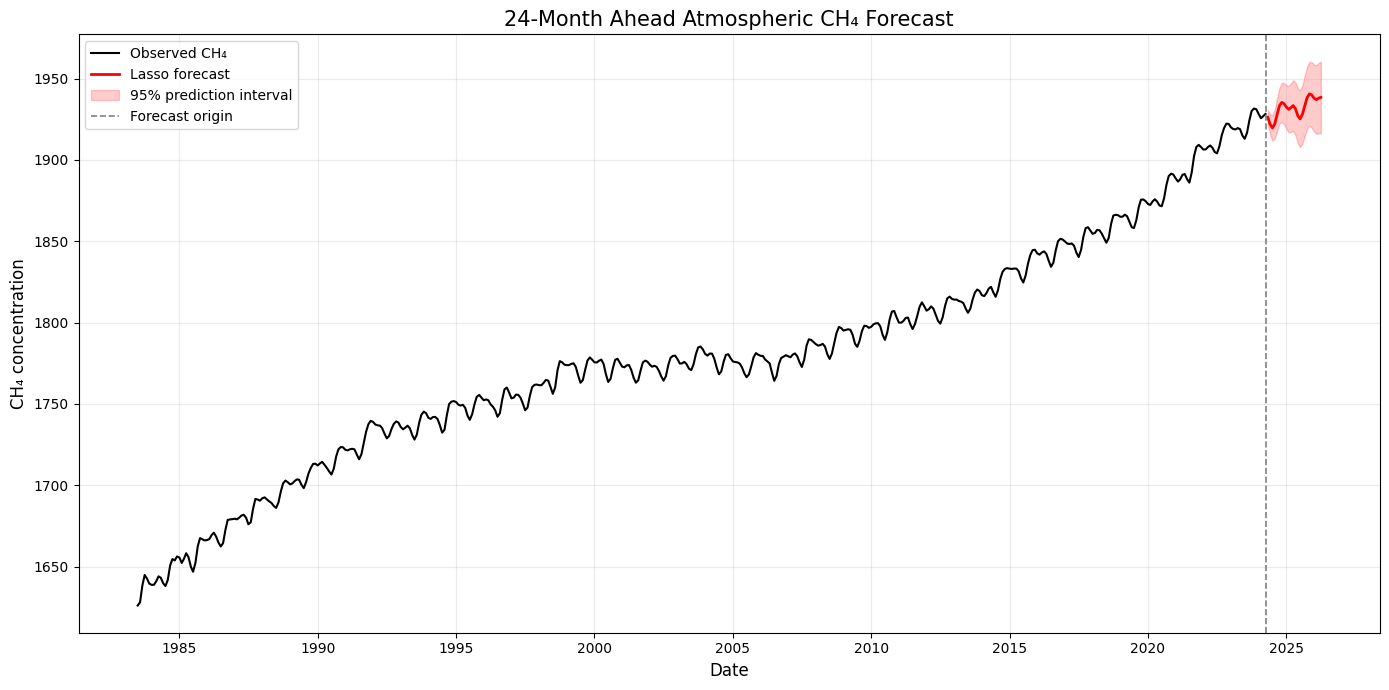


FILES SAVED
CH4_24_month_forecast_with_PI.png
CH4_24_month_forecast_with_PI.csv


In [ ]:
# ============================================================
# 24-MONTH CH4 FORECAST + 95% PREDICTION INTERVAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Settings
# ============================================================

target_col = "average"

forecast_horizon = 24

best_alpha = 0.001082636733874054

confidence_level = 0.95


# ============================================================
# 2. Prepare historical data
# ============================================================

historical_data = train.copy()

historical_data = historical_data.sort_index()

y_original = historical_data[target_col].copy()


# ============================================================
# 3. Create historical feature matrix
# ============================================================

ch4_features = create_ch4_features(
    historical_data,
    target_col=target_col
)

X_full = ch4_features.drop(
    columns=[target_col]
)

y_full = ch4_features[target_col]


# ============================================================
# 4. Define final Lasso model
# ============================================================

final_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=best_alpha,
        max_iter=100000
    ))
])


# ============================================================
# 5. Estimate historical out-of-fold residuals
# ============================================================
#
# These residuals are used to estimate forecast uncertainty.
#
# IMPORTANT:
# We use chronological folds rather than random CV.
#
# The model is fitted separately in each fold, and residuals
# are obtained only for observations that were not used to fit
# that fold.
# ============================================================

tscv_residuals = TimeSeriesSplit(
    n_splits=5
)

oof_predictions = pd.Series(
    index=y_full.index,
    dtype=float
)

for fold, (train_idx, test_idx) in enumerate(
    tscv_residuals.split(X_full),
    start=1
):

    X_train = X_full.iloc[train_idx]
    X_test = X_full.iloc[test_idx]

    y_train = y_full.iloc[train_idx]

    fold_model = clone(final_lasso)

    fold_model.fit(
        X_train,
        y_train
    )

    oof_predictions.iloc[test_idx] = (
        fold_model.predict(X_test)
    )


# Remove observations for which an OOF prediction
# was not available.

valid_residuals = (
    y_full[oof_predictions.notna()]
    - oof_predictions[oof_predictions.notna()]
)


# ============================================================
# 6. Calculate residual uncertainty
# ============================================================

residual_std = valid_residuals.std(ddof=1)

print("=" * 70)
print("OUT-OF-FOLD RESIDUAL UNCERTAINTY")
print("=" * 70)

print(
    f"Number of OOF residuals: "
    f"{len(valid_residuals)}"
)

print(
    f"Residual standard deviation: "
    f"{residual_std:.4f}"
)

print()


# ============================================================
# 7. Fit final model on ALL historical data
# ============================================================

final_lasso.fit(
    X_full,
    y_full
)


# ============================================================
# 8. Prepare recursive forecasting series
# ============================================================

forecast_series = historical_data[target_col].copy()

forecast_series = forecast_series.sort_index()


# ============================================================
# 9. Generate future dates
# ============================================================

last_observed_date = forecast_series.index[-1]

future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)


# ============================================================
# 10. Recursive forecasting
# ============================================================

future_predictions = []


for future_date in future_dates:

    # --------------------------------------------------------
    # Create temporary dataset containing historical values
    # and predictions generated so far.
    # --------------------------------------------------------

    temp_df = pd.DataFrame({
        target_col: forecast_series
    })

    # Temporary placeholder.
    #
    # The target at the forecast date itself is not used by
    # any of the engineered predictors because all predictors
    # are lagged by at least one month.

    temp_df.loc[
        future_date,
        target_col
    ] = 0.0

    temp_df = temp_df.sort_index()


    # --------------------------------------------------------
    # Generate features
    # --------------------------------------------------------

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Check future row
    # --------------------------------------------------------

    if future_date not in temp_features.index:

        raise ValueError(
            f"Could not create features for {future_date}"
        )


    # --------------------------------------------------------
    # Extract future predictors
    # --------------------------------------------------------

    X_future = temp_features.loc[
        [future_date]
    ].drop(
        columns=[target_col]
    )


    # --------------------------------------------------------
    # Forecast
    # --------------------------------------------------------

    prediction = final_lasso.predict(
        X_future
    )[0]


    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    future_predictions.append(
        prediction
    )


    # --------------------------------------------------------
    # Add prediction to series so that the next forecast can
    # use it as historical information.
    # --------------------------------------------------------

    forecast_series.loc[
        future_date
    ] = prediction


# ============================================================
# 11. Create forecast dataframe
# ============================================================

forecast_df = pd.DataFrame({
    "forecast": future_predictions
}, index=future_dates)


# ============================================================
# 12. Construct 95% prediction intervals
# ============================================================
#
# A simple residual-based interval is:
#
# forecast +/- z * residual_std
#
# But for recursive multi-step forecasting, uncertainty tends
# to increase with the forecast horizon.
#
# Therefore we scale the residual uncertainty approximately
# with sqrt(h).
#
# This gives:
#
#   h = 1  ->  residual_std
#   h = 4  ->  2 * residual_std
#   h = 9  ->  3 * residual_std
#   h = 16 ->  4 * residual_std
#
# This is a practical approximation, not an exact analytical
# prediction interval.
# ============================================================

z_value = 1.96

horizon = np.arange(
    1,
    forecast_horizon + 1
)

forecast_std = (
    residual_std
    * np.sqrt(horizon)
)

forecast_df["lower_95"] = (
    forecast_df["forecast"]
    - z_value * forecast_std
)

forecast_df["upper_95"] = (
    forecast_df["forecast"]
    + z_value * forecast_std
)


# ============================================================
# 13. Display forecast table
# ============================================================

print("=" * 70)
print("24-MONTH CH4 FORECAST")
print("=" * 70)

print(
    forecast_df.to_string(
        formatters={
            "forecast": "{:.4f}".format,
            "lower_95": "{:.4f}".format,
            "upper_95": "{:.4f}".format
        }
    )
)


# ============================================================
# 14. Plot historical data + forecast + prediction interval
# ============================================================

plt.figure(
    figsize=(14, 7)
)


# ------------------------------------------------------------
# Historical observations
# ------------------------------------------------------------

plt.plot(
    historical_data.index,
    historical_data[target_col],
    color="black",
    linewidth=1.5,
    label="Observed CH₄"
)


# ------------------------------------------------------------
# Forecast
# ------------------------------------------------------------

plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    color="red",
    linewidth=2,
    label="Lasso forecast"
)


# ------------------------------------------------------------
# Prediction interval
# ------------------------------------------------------------

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="red",
    alpha=0.20,
    label="95% prediction interval"
)


# ------------------------------------------------------------
# Forecast start
# ------------------------------------------------------------

plt.axvline(
    x=last_observed_date,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Forecast origin"
)


# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.title(
    "24-Month Ahead Atmospheric CH₄ Forecast",
    fontsize=15
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# 15. Save figure
# ============================================================

plt.savefig(
    "CH4_24_month_forecast_with_PI.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. Save forecast table
# ============================================================

forecast_df.to_csv(
    "CH4_24_month_forecast_with_PI.csv"
)


print()
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "CH4_24_month_forecast_with_PI.png"
)

print(
    "CH4_24_month_forecast_with_PI.csv"
)


OUT-OF-FOLD RESIDUAL UNCERTAINTY
Number of OOF residuals: 365
Residual standard deviation: 0.9514

24-MONTH CH4 FORECAST
            forecast  lower_95  upper_95
2024-05-01 1927.0710 1925.2063 1928.9358
2024-06-01 1923.9702 1921.3330 1926.6074
2024-07-01 1922.4870 1919.2571 1925.7169
2024-08-01 1925.5809 1921.8513 1929.3104
2024-09-01 1932.1908 1928.0211 1936.3606
2024-10-01 1937.6980 1933.1302 1942.2657
2024-11-01 1939.2880 1934.3543 1944.2217
2024-12-01 1938.6398 1933.3654 1943.9141
2025-01-01 1937.1729 1931.5786 1942.7672
2025-02-01 1936.0942 1930.1973 1941.9911
2025-03-01 1937.1154 1930.9306 1943.3001
2025-04-01 1938.6000 1932.1402 1945.0597
2025-05-01 1937.6204 1930.8969 1944.3440
2025-06-01 1934.5491 1927.5718 1941.5265
2025-07-01 1933.0734 1925.8511 1940.2956
2025-08-01 1936.0185 1928.5594 1943.4776
2025-09-01 1942.4223 1934.7336 1950.1109
2025-10-01 1948.2909 1940.3794 1956.2025
2025-11-01 1950.6291 1942.5008 1958.7575
2025-12-01 1950.2845 1941.9450 1958.6240
2026-01-01 1949.31

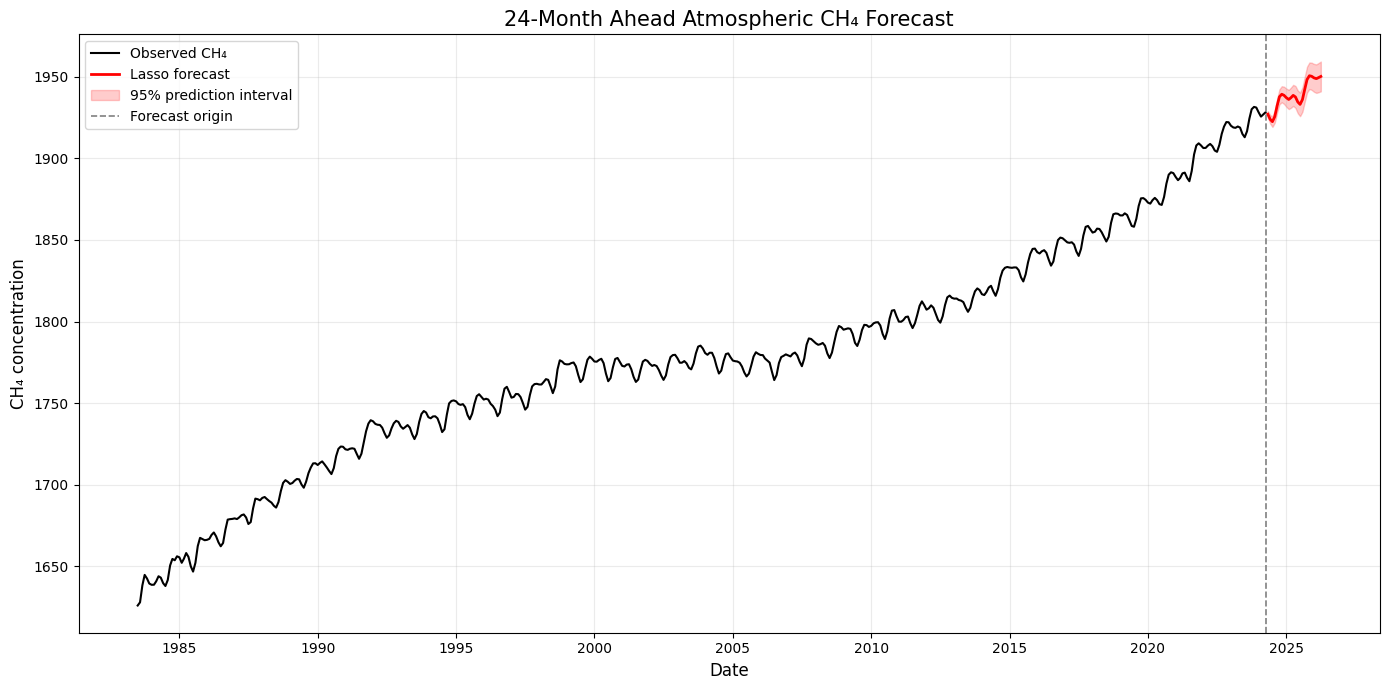


FILES SAVED
CH4_24_month_forecast_with_PI.png
CH4_24_month_forecast_with_PI.csv


In [29]:
# ============================================================
# 24-MONTH CH4 FORECAST + 95% PREDICTION INTERVAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
##from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Settings
# ============================================================

target_col = "average"

forecast_horizon = 24

best_alpha = 0.001082636733874054
#best_alpha = 0.00018329807108324357

#best_l1_ratio = 0.2

confidence_level = 0.95


# ============================================================
# 2. Prepare historical data
# ============================================================

historical_data = train.copy()

historical_data = historical_data.sort_index()

y_original = historical_data[target_col].copy()


# ============================================================
# 3. Create historical feature matrix
# ============================================================

ch4_features = create_ch4_features(
    historical_data,
    target_col=target_col
)

# IMPORTANT:
# Use EXACTLY the same feature-selection function
# that was used during model training.

X_full = select_model_features(
    ch4_features,
    target_col=target_col
)

y_full = ch4_features[target_col]


# ============================================================
# 4. Define final Lasso model
# ============================================================

final_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=best_alpha,
        max_iter=100000
    ))
])

#final_lasso = Pipeline([
    #("scaler", StandardScaler()),
    #("model", ElasticNet(
        #alpha=best_alpha,
        #l1_ratio=best_l1_ratio,
        #max_iter=100000
    #))
#])



# ============================================================
# 5. Estimate historical out-of-fold residuals
# ============================================================
#
# These residuals are used to estimate forecast uncertainty.
#
# IMPORTANT:
# We use chronological folds rather than random CV.
#
# The model is fitted separately in each fold, and residuals
# are obtained only for observations that were not used to fit
# that fold.
# ============================================================

tscv_residuals = TimeSeriesSplit(
    n_splits=5
)

oof_predictions = pd.Series(
    index=y_full.index,
    dtype=float
)

for fold, (train_idx, test_idx) in enumerate(
    tscv_residuals.split(X_full),
    start=1
):

    X_train = X_full.iloc[train_idx]
    X_test = X_full.iloc[test_idx]

    y_train = y_full.iloc[train_idx]

    fold_model = clone(final_lasso)

    fold_model.fit(
        X_train,
        y_train
    )

    oof_predictions.iloc[test_idx] = (
        fold_model.predict(X_test)
    )


# Remove observations for which an OOF prediction
# was not available.

valid_residuals = (
    y_full[oof_predictions.notna()]
    - oof_predictions[oof_predictions.notna()]
)


# ============================================================
# 6. Calculate residual uncertainty
# ============================================================

residual_std = valid_residuals.std(ddof=1)

print("=" * 70)
print("OUT-OF-FOLD RESIDUAL UNCERTAINTY")
print("=" * 70)

print(
    f"Number of OOF residuals: "
    f"{len(valid_residuals)}"
)

print(
    f"Residual standard deviation: "
    f"{residual_std:.4f}"
)

print()


# ============================================================
# 7. Fit final model on ALL historical data
# ============================================================

final_lasso.fit(
    X_full,
    y_full
)


# ============================================================
# 8. Prepare recursive forecasting series
# ============================================================

forecast_series = historical_data[target_col].copy()

forecast_series = forecast_series.sort_index()


# ============================================================
# 9. Generate future dates
# ============================================================

last_observed_date = forecast_series.index[-1]

future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)


# ============================================================
# 10. Recursive forecasting
# ============================================================

future_predictions = []


for future_date in future_dates:

    # --------------------------------------------------------
    # Create temporary dataset containing historical values
    # and predictions generated so far.
    # --------------------------------------------------------

    temp_df = pd.DataFrame({
        target_col: forecast_series
    })

    # Temporary placeholder.
    #
    # The target at the forecast date itself is not used by
    # any of the engineered predictors because all predictors
    # are lagged by at least one month.

    temp_df.loc[
        future_date,
        target_col
    ] = 0.0

    temp_df = temp_df.sort_index()


    # --------------------------------------------------------
    # Generate features
    # --------------------------------------------------------

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Apply EXACT SAME feature selection used during training
    # --------------------------------------------------------

    temp_features = select_model_features(
        temp_features,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Check future row
    # --------------------------------------------------------

    if future_date not in temp_features.index:

        raise ValueError(
            f"Could not create features for {future_date}"
        )


    # --------------------------------------------------------
    # Extract future predictors
    # --------------------------------------------------------

    X_future = temp_features.loc[
        [future_date]
    ]


    # --------------------------------------------------------
    # Ensure EXACT same feature order as training
    # --------------------------------------------------------

    X_future = X_future[
        X_full.columns
    ]


    # --------------------------------------------------------
    # Forecast
    # --------------------------------------------------------

    prediction = final_lasso.predict(
        X_future
    )[0]


    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    future_predictions.append(
        prediction
    )


    # --------------------------------------------------------
    # Add prediction to series so that the next forecast can
    # use it as historical information.
    # --------------------------------------------------------

    forecast_series.loc[
        future_date
    ] = prediction


# ============================================================
# 11. Create forecast dataframe
# ============================================================

forecast_df = pd.DataFrame({
    "forecast": future_predictions
}, index=future_dates)


# ============================================================
# 12. Construct 95% prediction intervals
# ============================================================
#
# A simple residual-based interval is:
#
# forecast +/- z * residual_std
#
# But for recursive multi-step forecasting, uncertainty tends
# to increase with the forecast horizon.
#
# Therefore we scale the residual uncertainty approximately
# with sqrt(h).
#
# This gives:
#
#   h = 1  ->  residual_std
#   h = 4  ->  2 * residual_std
#   h = 9  ->  3 * residual_std
#   h = 16 ->  4 * residual_std
#
# This is a practical approximation, not an exact analytical
# prediction interval.
# ============================================================

z_value = 1.96

horizon = np.arange(
    1,
    forecast_horizon + 1
)

forecast_std = (
    residual_std
    * np.sqrt(horizon)
)

forecast_df["lower_95"] = (
    forecast_df["forecast"]
    - z_value * forecast_std
)

forecast_df["upper_95"] = (
    forecast_df["forecast"]
    + z_value * forecast_std
)


# ============================================================
# 13. Display forecast table
# ============================================================

print("=" * 70)
print("24-MONTH CH4 FORECAST")
print("=" * 70)

print(
    forecast_df.to_string(
        formatters={
            "forecast": "{:.4f}".format,
            "lower_95": "{:.4f}".format,
            "upper_95": "{:.4f}".format
        }
    )
)


# ============================================================
# 14. Plot historical data + forecast + prediction interval
# ============================================================

plt.figure(
    figsize=(14, 7)
)


# ------------------------------------------------------------
# Historical observations
# ------------------------------------------------------------

plt.plot(
    historical_data.index,
    historical_data[target_col],
    color="black",
    linewidth=1.5,
    label="Observed CH₄"
)


# ------------------------------------------------------------
# Forecast
# ------------------------------------------------------------

plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    color="red",
    linewidth=2,
    label="Lasso forecast"
)


# ------------------------------------------------------------
# Prediction interval
# ------------------------------------------------------------

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="red",
    alpha=0.20,
    label="95% prediction interval"
)


# ------------------------------------------------------------
# Forecast start
# ------------------------------------------------------------

plt.axvline(
    x=last_observed_date,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Forecast origin"
)


# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.title(
    "24-Month Ahead Atmospheric CH₄ Forecast",
    fontsize=15
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# 15. Save figure
# ============================================================

plt.savefig(
    "CH4_24_month_forecast_with_PI.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. Save forecast table
# ============================================================

forecast_df.to_csv(
    "CH4_24_month_forecast_with_PI.csv"
)


print()
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "CH4_24_month_forecast_with_PI.png"
)

print(
    "CH4_24_month_forecast_with_PI.csv"
)


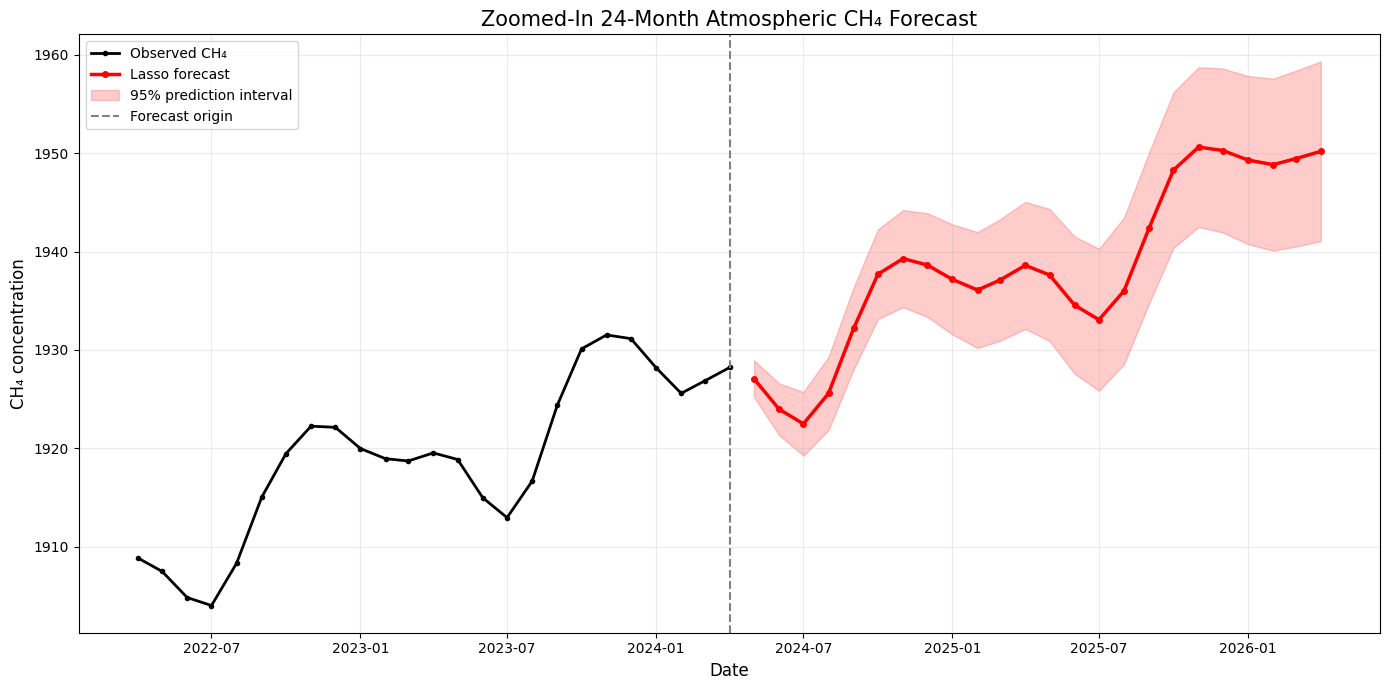

In [30]:
# ============================================================
# ZOOMED-IN FORECAST PLOT
# ============================================================

# Number of historical months to display before the forecast
# starts. Adjust this if you want a wider/narrower context.
zoom_history_months = 24


# ------------------------------------------------------------
# Determine zoomed-in start date
# ------------------------------------------------------------

zoom_start_date = (
    last_observed_date
    - pd.DateOffset(months=zoom_history_months)
)


# ------------------------------------------------------------
# Select historical observations for zoomed plot
# ------------------------------------------------------------

historical_zoom = historical_data.loc[
    historical_data.index >= zoom_start_date
]


# ============================================================
# Create figure
# ============================================================

plt.figure(
    figsize=(14, 7)
)


# ------------------------------------------------------------
# Historical CH4
# ------------------------------------------------------------

plt.plot(
    historical_zoom.index,
    historical_zoom[target_col],
    color="black",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Observed CH₄"
)


# ------------------------------------------------------------
# Forecast
# ------------------------------------------------------------

plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Lasso forecast"
)


# ------------------------------------------------------------
# 95% prediction interval
# ------------------------------------------------------------

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="red",
    alpha=0.20,
    label="95% prediction interval"
)


# ------------------------------------------------------------
# Forecast origin
# ------------------------------------------------------------

plt.axvline(
    x=last_observed_date,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)


# ============================================================
# Formatting
# ============================================================

plt.title(
    "Zoomed-In 24-Month Atmospheric CH₄ Forecast",
    fontsize=15
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# Save zoomed plot
# ============================================================

plt.savefig(
    "CH4_24_month_forecast_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [15]:
# ============================================================
# ONE-STEP-AHEAD HOLDOUT FORECAST WITH ACTUAL UPDATES
# USING BEST ELASTIC NET MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet


# ============================================================
# 1. Settings
# ============================================================

target_col = "average"

holdout_months = 24

best_alpha = 0.00018329807108324357
best_l1_ratio = 0.2


# ============================================================
# 2. Split data chronologically
# ============================================================

df = df.sort_index()

training_data = df.iloc[:-holdout_months].copy()

holdout = df.iloc[-holdout_months:].copy()

holdout = holdout.sort_index()


print("=" * 70)
print("DATA SPLIT")
print("=" * 70)

print(
    "Training period:",
    training_data.index[0],
    "to",
    training_data.index[-1]
)

print(
    "Holdout period:",
    holdout.index[0],
    "to",
    holdout.index[-1]
)

print()


# ============================================================
# 3. Create training features
# ============================================================

training_features = create_ch4_features(
    training_data,
    target_col=target_col
)


# ============================================================
# 4. Apply EXACT SAME feature selection
# ============================================================

X_train = select_model_features(
    training_features,
    target_col=target_col
)

y_train = training_features[target_col]


# ============================================================
# 5. Define Elastic Net
# ============================================================

final_elastic_net = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
        max_iter=100000
    ))
])


# ============================================================
# 6. Fit ONLY on pre-holdout data
# ============================================================

final_elastic_net.fit(
    X_train,
    y_train
)


print("=" * 70)
print("ELASTIC NET")
print("=" * 70)

print("Alpha:", best_alpha)
print("L1 ratio:", best_l1_ratio)
print("Training observations:", len(X_train))
print("Number of predictors:", X_train.shape[1])

print()


# ============================================================
# 7. Create series containing ONLY information available
#    at each forecasting point
# ============================================================

observed_series = training_data[target_col].copy()

observed_series = observed_series.sort_index()


# ============================================================
# 8. Sequential one-step-ahead forecasting
# ============================================================

holdout_predictions = []


for forecast_date in holdout.index:

    # --------------------------------------------------------
    # At this point:
    #
    # observed_series contains:
    #
    #   all training observations
    #   +
    #   ACTUAL holdout observations that have already occurred
    #
    # It does NOT contain the current forecast_date.
    # --------------------------------------------------------

    temp_df = pd.DataFrame({
        target_col: observed_series
    })


    # --------------------------------------------------------
    # Add current date with a temporary placeholder.
    #
    # This is safe because every target-derived predictor
    # in create_ch4_features() uses shift(1) or older.
    #
    # Therefore the placeholder cannot enter the predictors
    # for forecast_date.
    # --------------------------------------------------------

    temp_df.loc[
        forecast_date,
        target_col
    ] = 0.0

    temp_df = temp_df.sort_index()


    # --------------------------------------------------------
    # Engineer features
    # --------------------------------------------------------

    temp_features = create_ch4_features(
        temp_df,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Apply EXACT SAME feature selection used for training
    # --------------------------------------------------------

    temp_features = select_model_features(
        temp_features,
        target_col=target_col
    )


    # --------------------------------------------------------
    # Make sure the forecast row exists
    # --------------------------------------------------------

    if forecast_date not in temp_features.index:

        raise ValueError(
            f"Could not create features for {forecast_date}"
        )


    # --------------------------------------------------------
    # Extract predictors for CURRENT date
    # --------------------------------------------------------

    X_future = temp_features.loc[
        [forecast_date]
    ]


    # --------------------------------------------------------
    # Force exactly the same column order as training
    # --------------------------------------------------------

    X_future = X_future[
        X_train.columns
    ]


    # --------------------------------------------------------
    # Predict CURRENT date
    # --------------------------------------------------------

    prediction = final_elastic_net.predict(
        X_future
    )[0]


    # --------------------------------------------------------
    # Retrieve ACTUAL value
    # --------------------------------------------------------

    actual = holdout.loc[
        forecast_date,
        target_col
    ]


    # --------------------------------------------------------
    # Store prediction and actual
    # --------------------------------------------------------

    holdout_predictions.append({
        "date": forecast_date,
        "actual": actual,
        "forecast": prediction
    })


    # --------------------------------------------------------
    # CRITICAL STEP
    #
    # Do NOT append the prediction.
    #
    # Append the ACTUAL observed value.
    #
    # This simulates what happens in real operation:
    #
    # predict t
    # ↓
    # actual t becomes available
    # ↓
    # use actual t to predict t+1
    # --------------------------------------------------------

    observed_series.loc[
        forecast_date
    ] = actual


# ============================================================
# 9. Create results dataframe
# ============================================================

holdout_results = pd.DataFrame(
    holdout_predictions
)

holdout_results = holdout_results.set_index(
    "date"
)


# ============================================================
# 10. Calculate errors
# ============================================================

holdout_results["error"] = (
    holdout_results["actual"]
    - holdout_results["forecast"]
)

holdout_results["absolute_error"] = (
    holdout_results["error"].abs()
)

holdout_results["squared_error"] = (
    holdout_results["error"] ** 2
)


# ============================================================
# 11. Performance metrics
# ============================================================

mae = (
    holdout_results["absolute_error"]
    .mean()
)

rmse = np.sqrt(
    holdout_results["squared_error"].mean()
)


print("=" * 70)
print("ONE-STEP-AHEAD HOLDOUT PERFORMANCE")
print("=" * 70)

print(
    f"MAE:  {mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print()


# ============================================================
# 12. Display results
# ============================================================

print("=" * 70)
print("HOLDOUT PREDICTIONS")
print("=" * 70)

print(
    holdout_results[
        [
            "actual",
            "forecast",
            "error",
            "absolute_error"
        ]
    ].to_string(
        formatters={
            "actual": "{:.4f}".format,
            "forecast": "{:.4f}".format,
            "error": "{:.4f}".format,
            "absolute_error": "{:.4f}".format
        }
    )
)


DATA SPLIT
Training period: 1983-07-01 00:00:00 to 2024-04-01 00:00:00
Holdout period: 2024-05-01 00:00:00 to 2026-04-01 00:00:00

ELASTIC NET
Alpha: 0.00018329807108324357
L1 ratio: 0.2
Training observations: 442
Number of predictors: 17

ONE-STEP-AHEAD HOLDOUT PERFORMANCE
MAE:  0.7372
RMSE: 0.9776

HOLDOUT PREDICTIONS
              actual  forecast   error absolute_error
date                                                 
2024-05-01 1925.4100 1927.0380 -1.6280         1.6280
2024-06-01 1921.3700 1921.1090  0.2610         0.2610
2024-07-01 1920.4000 1920.5475 -0.1475         0.1475
2024-08-01 1924.7900 1924.0818  0.7082         0.7082
2024-09-01 1934.2400 1931.8187  2.4213         2.4213
2024-10-01 1940.7100 1941.0410 -0.3310         0.3310
2024-11-01 1940.0900 1940.6048 -0.5148         0.5148
2024-12-01 1937.6200 1936.9718  0.6482         0.6482
2025-01-01 1935.7400 1935.9642 -0.2242         0.2242
2025-02-01 1934.3900 1934.6508 -0.2608         0.2608
2025-03-01 1934.0200 1935.3540

ROLLING ONE-STEP-AHEAD HOLDOUT RESULTS
              actual  forecast  lower_95  upper_95   error absolute_error
date                                                                     
2024-05-01 1925.4100 1927.0380 1925.1102 1928.9658 -1.6280         1.6280
2024-06-01 1921.3700 1921.1090 1919.1812 1923.0368  0.2610         0.2610
2024-07-01 1920.4000 1920.5475 1918.6198 1922.4753 -0.1475         0.1475
2024-08-01 1924.7900 1924.0818 1922.1540 1926.0096  0.7082         0.7082
2024-09-01 1934.2400 1931.8187 1929.8909 1933.7464  2.4213         2.4213
2024-10-01 1940.7100 1941.0410 1939.1132 1942.9688 -0.3310         0.3310
2024-11-01 1940.0900 1940.6048 1938.6770 1942.5325 -0.5148         0.5148
2024-12-01 1937.6200 1936.9718 1935.0440 1938.8995  0.6482         0.6482
2025-01-01 1935.7400 1935.9642 1934.0364 1937.8919 -0.2242         0.2242
2025-02-01 1934.3900 1934.6508 1932.7230 1936.5786 -0.2608         0.2608
2025-03-01 1934.0200 1935.3540 1933.4262 1937.2818 -1.3340         1.3340

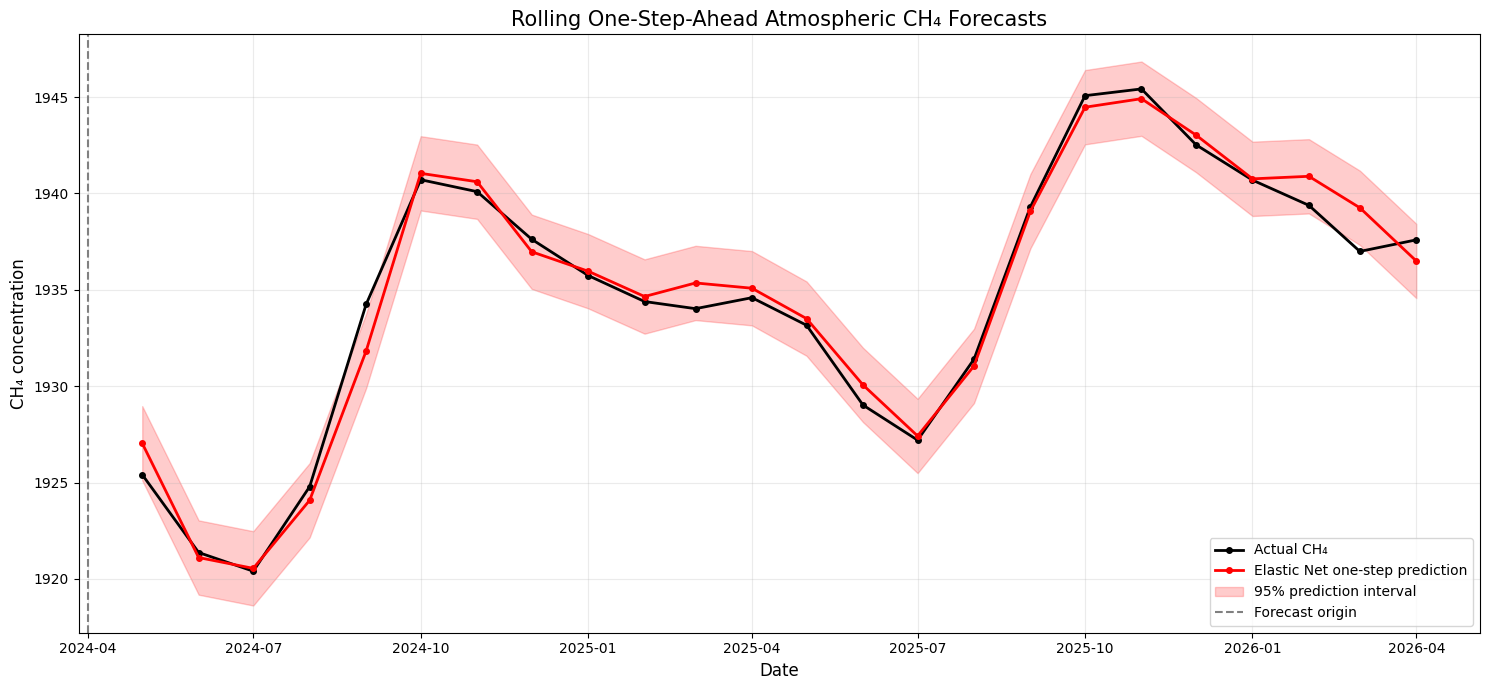


FILES SAVED
CH4_rolling_holdout_forecast_with_95_CI.png
CH4_rolling_holdout_forecast_with_95_CI.csv


In [16]:
# ============================================================
# 13. Construct 95% prediction intervals for holdout
# ============================================================
#
# These are ONE-STEP-AHEAD predictions.
#
# Therefore, unlike the 24-month recursive forecast, we do NOT
# need to inflate uncertainty using sqrt(horizon).
#
# Each prediction is for one month ahead and uses all actual
# observations available up to the previous month.
# ============================================================

confidence_level = 0.95

z_value = 1.96

# ------------------------------------------------------------
# Estimate residual standard deviation from the rolling
# one-step-ahead holdout predictions.
# ------------------------------------------------------------

residual_std = (
    holdout_results["actual"]
    - holdout_results["forecast"]
).std(ddof=1)


# ------------------------------------------------------------
# Add prediction intervals
# ------------------------------------------------------------

holdout_results["lower_95"] = (
    holdout_results["forecast"]
    - z_value * residual_std
)

holdout_results["upper_95"] = (
    holdout_results["forecast"]
    + z_value * residual_std
)


# ============================================================
# 14. Display holdout results
# ============================================================

print("=" * 70)
print("ROLLING ONE-STEP-AHEAD HOLDOUT RESULTS")
print("=" * 70)

print(
    holdout_results[
        [
            "actual",
            "forecast",
            "lower_95",
            "upper_95",
            "error",
            "absolute_error"
        ]
    ].to_string(
        formatters={
            "actual": "{:.4f}".format,
            "forecast": "{:.4f}".format,
            "lower_95": "{:.4f}".format,
            "upper_95": "{:.4f}".format,
            "error": "{:.4f}".format,
            "absolute_error": "{:.4f}".format
        }
    )
)


# ============================================================
# 15. Plot rolling predictions + 95% CI against actual holdout
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual holdout observations
# ------------------------------------------------------------

plt.plot(
    holdout_results.index,
    holdout_results["actual"],
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Actual CH₄"
)


# ------------------------------------------------------------
# Rolling one-step-ahead predictions
# ------------------------------------------------------------

plt.plot(
    holdout_results.index,
    holdout_results["forecast"],
    color="red",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Elastic Net one-step prediction"
)


# ------------------------------------------------------------
# 95% prediction interval
# ------------------------------------------------------------

plt.fill_between(
    holdout_results.index,
    holdout_results["lower_95"],
    holdout_results["upper_95"],
    color="red",
    alpha=0.20,
    label="95% prediction interval"
)


# ------------------------------------------------------------
# Training / holdout boundary
# ------------------------------------------------------------

plt.axvline(
    x=training_data.index[-1],
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.title(
    "Rolling One-Step-Ahead Atmospheric CH₄ Forecasts",
    fontsize=15
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)


# ------------------------------------------------------------
# Legend and grid
# ------------------------------------------------------------

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# 16. Save figure
# ============================================================

plt.savefig(
    "CH4_rolling_holdout_forecast_with_95_CI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. Save holdout results
# ============================================================

holdout_results.to_csv(
    "CH4_rolling_holdout_forecast_with_95_CI.csv"
)


print()
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "CH4_rolling_holdout_forecast_with_95_CI.png"
)

print(
    "CH4_rolling_holdout_forecast_with_95_CI.csv"
)


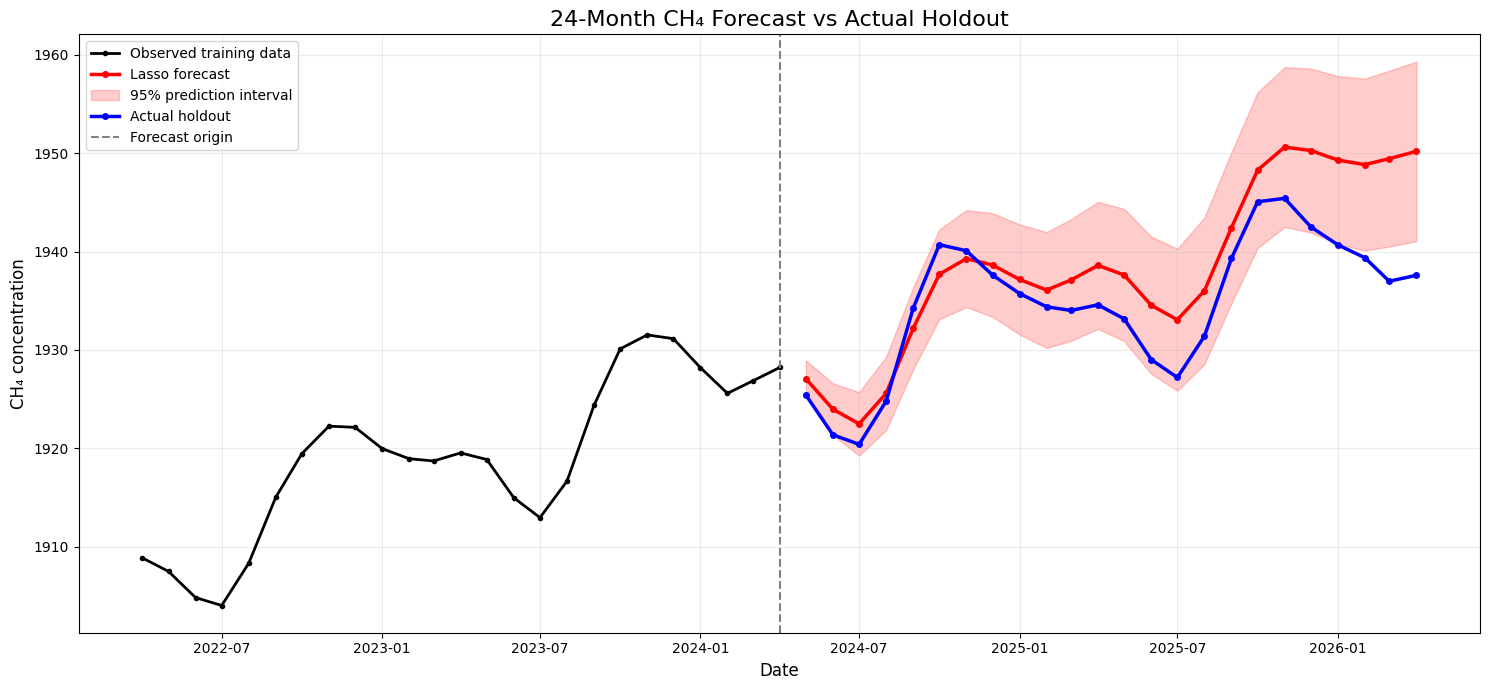

In [31]:
# ============================================================
# ZOOMED FORECAST VS ACTUAL HOLDOUT
# ============================================================
#
# IMPORTANT:
# The holdout data is ONLY used for plotting.
# It is NOT used for:
#   - model fitting
#   - feature engineering for the model
#   - hyperparameter tuning
#   - prediction intervals
#
# Therefore, this is a genuine out-of-sample comparison.
# ============================================================


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

zoom_history_months = 24


# ------------------------------------------------------------
# Holdout data
# ------------------------------------------------------------

# You already created this:
#
# holdout = df.iloc[-holdout_months:].copy()

holdout = holdout.sort_index()


# ------------------------------------------------------------
# Determine forecast origin
# ------------------------------------------------------------

last_training_date = holdout.index[0] - pd.offsets.MonthBegin(1)


# ------------------------------------------------------------
# Select historical data immediately before holdout
# ------------------------------------------------------------

zoom_start_date = (
    last_training_date
    - pd.DateOffset(months=zoom_history_months)
)


historical_zoom = historical_data.loc[
    historical_data.index >= zoom_start_date
]


# ============================================================
# Create plot
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ============================================================
# 1. Historical observations used for training
# ============================================================

plt.plot(
    historical_zoom.index,
    historical_zoom[target_col],
    color="black",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Observed training data"
)


# ============================================================
# 2. Lasso 24-month forecast
# ============================================================

plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Lasso forecast"
)


# ============================================================
# 3. 95% prediction interval
# ============================================================

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="red",
    alpha=0.20,
    label="95% prediction interval"
)


# ============================================================
# 4. Actual holdout observations
# ============================================================

plt.plot(
    holdout.index,
    holdout[target_col],
    color="blue",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Actual holdout"
)


# ============================================================
# 5. Forecast origin
# ============================================================

plt.axvline(
    x=last_training_date,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)


# ============================================================
# Formatting
# ============================================================

plt.title(
    "24-Month CH₄ Forecast vs Actual Holdout",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "CH4_forecast_vs_actual_holdout.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


In [32]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [33]:
forecast_triple = model_triple_fit.forecast(24)
print(forecast_triple)

2024-05-01    1926.979160
2024-06-01    1923.435190
2024-07-01    1921.004292
2024-08-01    1924.515993
2024-09-01    1932.158474
2024-10-01    1937.469416
2024-11-01    1938.919523
2024-12-01    1938.404772
2025-01-01    1937.255202
2025-02-01    1937.105963
2025-03-01    1938.200341
2025-04-01    1938.979945
2025-05-01    1937.739106
2025-06-01    1934.195135
2025-07-01    1931.764238
2025-08-01    1935.275939
2025-09-01    1942.918419
2025-10-01    1948.229362
2025-11-01    1949.679469
2025-12-01    1949.164717
2026-01-01    1948.015147
2026-02-01    1947.865908
2026-03-01    1948.960286
2026-04-01    1949.739891
Freq: MS, dtype: float64


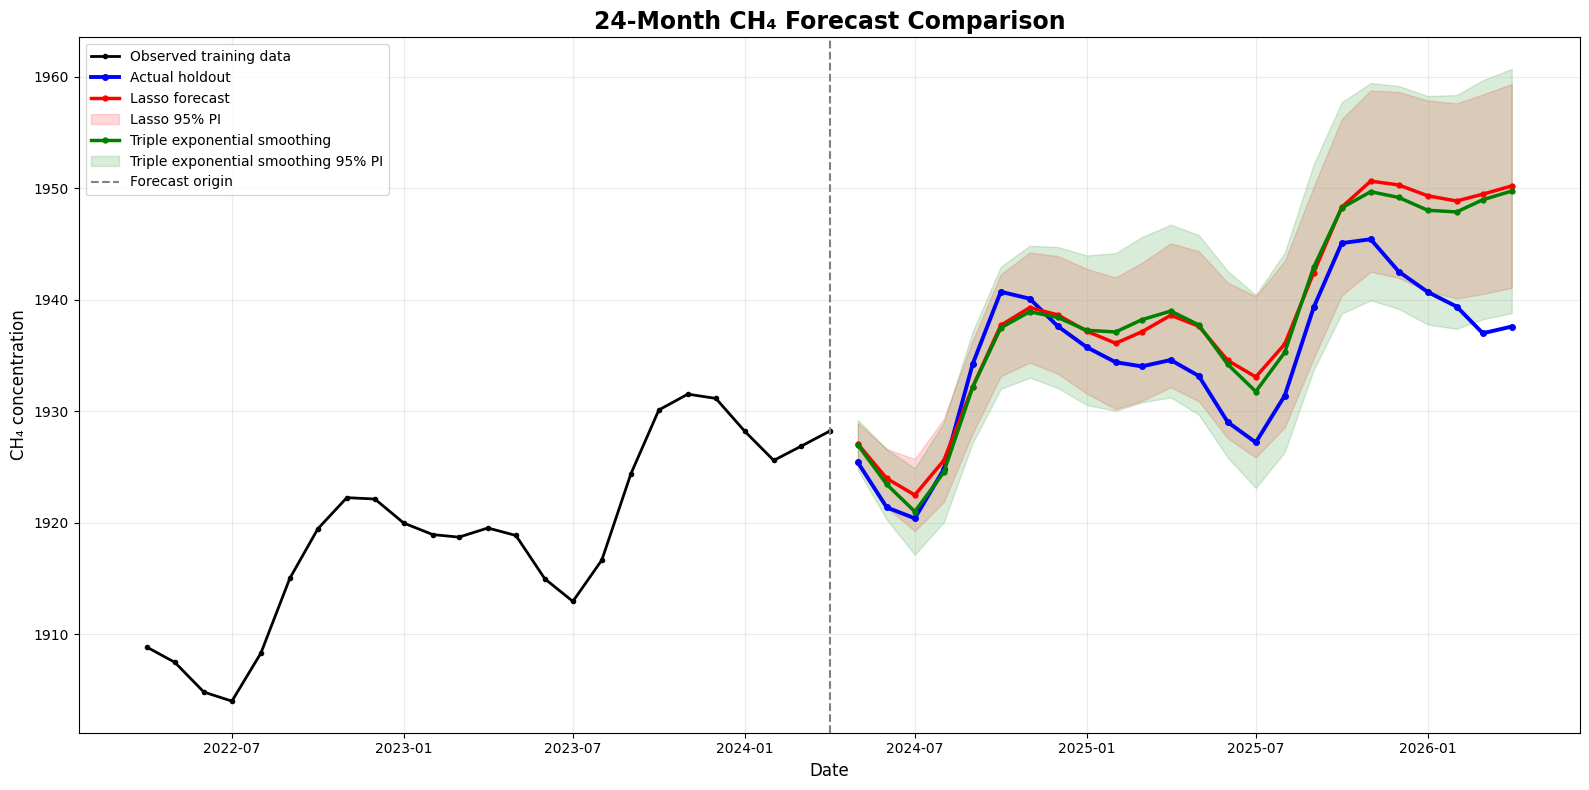


24-MONTH HOLDOUT MODEL COMPARISON
                       Model    MAE   RMSE     R2 MAPE (%)
                       Lasso 4.4673 5.5983 0.3285     0.23
Triple Exponential Smoothing 4.1829 5.2277 0.4145     0.22


In [34]:
# ============================================================
# COMPARE LASSO vs TRIPLE EXPONENTIAL SMOOTHING
# AGAINST 24-MONTH ACTUAL HOLDOUT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. Ensure forecast objects are Series with correct dates
# ============================================================

# Lasso forecast_df should already contain:
#
#   forecast
#   lower_95
#   upper_95
#
# with the future dates as its index.

lasso_forecast = forecast_df["forecast"].copy()

lasso_lower = forecast_df["lower_95"].copy()

lasso_upper = forecast_df["upper_95"].copy()


# ------------------------------------------------------------
# Exponential smoothing forecast
# ------------------------------------------------------------

forecast_triple = model_triple_fit.forecast(
    24
)

# Make sure it is a pandas Series
forecast_triple = pd.Series(
    forecast_triple,
    index=lasso_forecast.index,
    name="triple_forecast"
)


# ============================================================
# 2. Calculate prediction interval for exponential smoothing
# ============================================================
#
# statsmodels ExponentialSmoothing does not automatically give
# prediction intervals in the same way as some other models.
#
# We therefore estimate uncertainty from the historical
# in-sample residuals.
# ============================================================

triple_fitted = model_triple_fit.fittedvalues

triple_residuals = (
    train["average"]
    - triple_fitted
)

triple_residual_std = triple_residuals.std(
    ddof=1
)


# 95% normal critical value
z_value = 1.96


# Forecast horizon
h = np.arange(
    1,
    len(forecast_triple) + 1
)


# ------------------------------------------------------------
# Approximate increasing uncertainty with horizon
# ------------------------------------------------------------

triple_forecast_std = (
    triple_residual_std
    * np.sqrt(h)
)


triple_lower = (
    forecast_triple
    - z_value * triple_forecast_std
)

triple_upper = (
    forecast_triple
    + z_value * triple_forecast_std
)


# ============================================================
# 3. Prepare actual holdout observations
# ============================================================

holdout_actual = holdout["average"].copy()

holdout_actual = holdout_actual.sort_index()


# Ensure the forecast and holdout use the same dates
comparison = pd.DataFrame({
    "actual": holdout_actual,
    "lasso": lasso_forecast,
    "triple_exponential": forecast_triple
}).dropna()


# ============================================================
# 4. Determine forecast origin
# ============================================================

forecast_origin = train.index[-1]


# ============================================================
# 5. Select historical data for zoomed context
# ============================================================

zoom_history_months = 24

zoom_start = (
    forecast_origin
    - pd.DateOffset(
        months=zoom_history_months
    )
)


historical_zoom = train.loc[
    train.index >= zoom_start
]


# ============================================================
# 6. Create comparison plot
# ============================================================

plt.figure(
    figsize=(16, 8)
)


# ============================================================
# Historical training observations
# ============================================================

plt.plot(
    historical_zoom.index,
    historical_zoom["average"],
    color="black",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Observed training data"
)


# ============================================================
# Actual holdout observations
# ============================================================

plt.plot(
    holdout_actual.index,
    holdout_actual.values,
    color="blue",
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Actual holdout"
)


# ============================================================
# LASSO FORECAST
# ============================================================

plt.plot(
    lasso_forecast.index,
    lasso_forecast.values,
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Lasso forecast"
)


# ------------------------------------------------------------
# Lasso 95% prediction interval
# ------------------------------------------------------------

plt.fill_between(
    lasso_forecast.index,
    lasso_lower.values,
    lasso_upper.values,
    color="red",
    alpha=0.15,
    label="Lasso 95% PI"
)


# ============================================================
# TRIPLE EXPONENTIAL SMOOTHING FORECAST
# ============================================================

plt.plot(
    forecast_triple.index,
    forecast_triple.values,
    color="green",
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Triple exponential smoothing"
)


# ------------------------------------------------------------
# Triple exponential smoothing 95% PI
# ------------------------------------------------------------

plt.fill_between(
    forecast_triple.index,
    triple_lower.values,
    triple_upper.values,
    color="green",
    alpha=0.15,
    label="Triple exponential smoothing 95% PI"
)


# ============================================================
# Forecast origin
# ============================================================

plt.axvline(
    x=forecast_origin,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)


# ============================================================
# Formatting
# ============================================================

plt.title(
    "24-Month CH₄ Forecast Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best",
    fontsize=10
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "CH4_24_month_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 7. Calculate holdout performance
# ============================================================

actual = comparison["actual"]

lasso_pred = comparison["lasso"]

triple_pred = comparison["triple_exponential"]


# ------------------------------------------------------------
# Lasso metrics
# ------------------------------------------------------------

lasso_mae = mean_absolute_error(
    actual,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        actual,
        lasso_pred
    )
)

lasso_r2 = r2_score(
    actual,
    lasso_pred
)

lasso_mape = (
    np.mean(
        np.abs(
            (actual - lasso_pred)
            / actual
        )
    ) * 100
)


# ------------------------------------------------------------
# Triple exponential smoothing metrics
# ------------------------------------------------------------

triple_mae = mean_absolute_error(
    actual,
    triple_pred
)

triple_rmse = np.sqrt(
    mean_squared_error(
        actual,
        triple_pred
    )
)

triple_r2 = r2_score(
    actual,
    triple_pred
)

triple_mape = (
    np.mean(
        np.abs(
            (actual - triple_pred)
            / actual
        )
    ) * 100
)


# ============================================================
# 8. Print final holdout comparison
# ============================================================

comparison_results = pd.DataFrame({
    "Model": [
        "Lasso",
        "Triple Exponential Smoothing"
    ],

    "MAE": [
        lasso_mae,
        triple_mae
    ],

    "RMSE": [
        lasso_rmse,
        triple_rmse
    ],

    "R2": [
        lasso_r2,
        triple_r2
    ],

    "MAPE (%)": [
        lasso_mape,
        triple_mape
    ]
})


print()
print("=" * 80)
print("24-MONTH HOLDOUT MODEL COMPARISON")
print("=" * 80)

print(
    comparison_results.to_string(
        index=False,
        formatters={
            "MAE": "{:.4f}".format,
            "RMSE": "{:.4f}".format,
            "R2": "{:.4f}".format,
            "MAPE (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# 9. Save comparison metrics
# ============================================================

comparison_results.to_csv(
    "CH4_24_month_holdout_model_comparison.csv",
    index=False
)


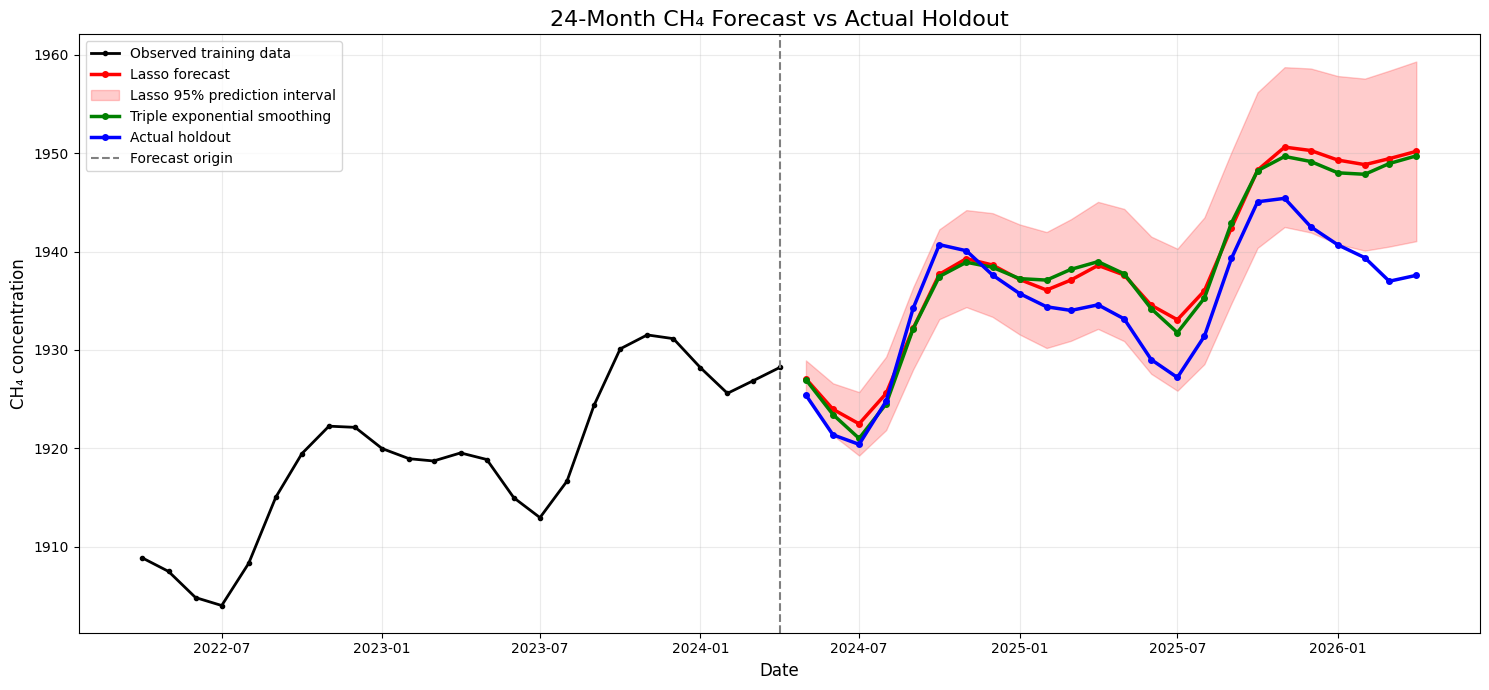

In [35]:
# ============================================================
# ZOOMED FORECAST VS ACTUAL HOLDOUT
# ============================================================

zoom_history_months = 24


# ------------------------------------------------------------
# Holdout data
# ------------------------------------------------------------

holdout = holdout.sort_index()


# ------------------------------------------------------------
# Determine forecast origin
# ------------------------------------------------------------

last_training_date = holdout.index[0] - pd.offsets.MonthBegin(1)


# ------------------------------------------------------------
# Select historical data immediately before forecast
# ------------------------------------------------------------

zoom_start_date = (
    last_training_date
    - pd.DateOffset(months=zoom_history_months)
)


historical_zoom = historical_data.loc[
    historical_data.index >= zoom_start_date
]


# ============================================================
# Create plot
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ============================================================
# 1. Historical observations used for training
# ============================================================

plt.plot(
    historical_zoom.index,
    historical_zoom[target_col],
    color="black",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Observed training data"
)


# ============================================================
# 2. Lasso 24-month forecast
# ============================================================

plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Lasso forecast"
)


# ============================================================
# 3. Lasso 95% prediction interval
# ============================================================

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    color="red",
    alpha=0.20,
    label="Lasso 95% prediction interval"
)


# ============================================================
# 4. Triple Exponential Smoothing forecast
# ============================================================

plt.plot(
    forecast_triple.index,
    forecast_triple.values,
    color="green",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Triple exponential smoothing"
)


# ============================================================
# 5. Actual holdout observations
# ============================================================

plt.plot(
    holdout.index,
    holdout[target_col],
    color="blue",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Actual holdout"
)


# ============================================================
# 6. Forecast origin
# ============================================================

plt.axvline(
    x=last_training_date,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)


# ============================================================
# Formatting
# ============================================================

plt.title(
    "24-Month CH₄ Forecast vs Actual Holdout",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "CH₄ concentration",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "CH4_forecast_vs_actual_holdout.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    return mae, rmse, r2, mape


# ============================================================
# Evaluate Naive baselines using the SAME CV folds
# ============================================================

naive_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    y_val = y.iloc[val_idx]

    # --------------------------------------------------------
    # Lag-1 naive forecast
    # --------------------------------------------------------

    naive_lag1 = X.iloc[val_idx]["lag_1"]

    metrics_lag1 = calculate_metrics(
        y_val,
        naive_lag1
    )

    naive_results.append({
        "Model": "Naive Lag-1",
        "Fold": fold,
        "MAE": metrics_lag1[0],
        "RMSE": metrics_lag1[1],
        "R2": metrics_lag1[2],
        "MAPE": metrics_lag1[3]
    })

    # --------------------------------------------------------
    # Seasonal naive forecast
    # --------------------------------------------------------

    naive_lag12 = X.iloc[val_idx]["lag_12"]

    metrics_lag12 = calculate_metrics(
        y_val,
        naive_lag12
    )

    naive_results.append({
        "Model": "Seasonal Naive Lag-12",
        "Fold": fold,
        "MAE": metrics_lag12[0],
        "RMSE": metrics_lag12[1],
        "R2": metrics_lag12[2],
        "MAPE": metrics_lag12[3]
    })


naive_results_df = pd.DataFrame(
    naive_results
)

print(
    naive_results_df
    .groupby("Model")
    [["MAE", "RMSE", "R2", "MAPE"]]
    .mean()
    .round(4)
)


                          MAE    RMSE      R2    MAPE
Model                                                
Naive Lag-1            2.5754  3.3370  0.8781  0.1425
Seasonal Naive Lag-12  6.7197  7.4527  0.6763  0.3674
